# Processing cell-attached spiking data for each motoneuron

In [88]:
# parent_folder_path = "/Users/haleyoro/Desktop/" # work on library computer
parent_folder_path = "/Users/Haley/Desktop/" # work on local computer

In [89]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import pyabf
import os
from waveforms_helpers import *
import pickle
from cellattachedspikes import *

In [90]:
with open("sheets.pkl", "rb") as f:
    sheets = pickle.load(f)

In [91]:
sheets.keys()

dict_keys(['2012_04_25_cell1', '2012_04_25_cell3', '2012_04_27_cell1', '2012_06_22_cell3', '2012_06_25_cell3', '2012_06_29', '2012_08_01_cell1', '2012_08_01_cell3', '2012_08_07', '2012_08_31_cell1', '2012_08_31_cell2', '2012_08_31_cell3', '2012_08_31_cell4', '2012_10_04_cell2', '2012_12_03_cell1', '2012_12_04_cell1', '2012_12_04_cell2', '2012_12_05_cell1', '2012_12_05_cell3', '2012_12_05_cell4', '2012_12_06_cell1', '2012_12_06_cell2', '2012_12_06_cell3', '2012_12_06_cell4', '2012_12_06_cell5', '2012_12_06_cell6', '2013_03_20_cell1', '2013_03_21_cell1', '2013_03_21_cell2', '2013_03_21_cell3', '2013_03_21_cell4', '2013_03_21_cell5', '2013_03_22_cell1', '2013_03_22_cell2', '2013_03_22_cell3', '2013_03_22_cell4', '2013_03_22_cell5', '2013_03_22_cell6', '2012_10_04_cell1'])

In [92]:
sheets['2012_04_25_cell1']

,Trace name,ID,On time,Freq,Tags,Type,Seconds,Cell Type,Input Resistance,Motoneuron
0,2012_04_25_0004,1,1285.99,NaN,bout start; shock,Inhibitory,1.28599,vRoP,74.45,primary
1,2012_04_25_0004,2,1305.92,50.1756,<NA>,Inhibitory,1.30592,vRoP,74.45,primary
2,2012_04_25_0004,3,1340.95,28.5470,<NA>,Inhibitory,1.34095,vRoP,74.45,primary
3,2012_04_25_0004,4,1371.30,32.9489,<NA>,Inhibitory,1.37130,vRoP,74.45,primary
4,2012_04_25_0004,5,1405.23,29.4724,bout end,Inhibitory,1.40523,vRoP,74.45,primary
...,...,...,...,...,...,...,...,...,...,...
153,2012_04_25_0002,13,4726.57,39.7141,<NA>,Excitatory,4.72657,vRoP,74.45,primary
154,2012_04_25_0002,14,4755.30,34.8068,<NA>,Excitatory,4.75530,vRoP,74.45,primary
155,2012_04_25_0002,15,4780.80,39.2157,<NA>,Excitatory,4.78080,vRoP,74.45,primary
156,2012_04_25_0002,16,4808.89,35.5999,<NA>,Excitatory,4.80889,vRoP,74.45,primary


In [93]:
matches, non_matches = split_cell_attached(sheets)

# print("✅ Sheets WITH Cell-attached traces:")
# for sheet, rows in matches.items():
#     print(f"  - {sheet} ({len(rows)} rows)")

print("\n❌ Sheets WITHOUT Cell-attached traces:")
for sheet in non_matches:
    print(f"  - {sheet}")


❌ Sheets WITHOUT Cell-attached traces:
  - 2012_04_25_cell1
  - 2012_04_25_cell3
  - 2012_04_27_cell1
  - 2012_06_22_cell3
  - 2012_06_25_cell3
  - 2012_06_29
  - 2013_03_22_cell3


In [94]:
matches, non_matches = split_cell_attached_spiking(sheets)

# print("✅ Sheets WITH Cell-attached traces:")
# for sheet, rows in matches.items():
#     print(f"  - {sheet} ({len(rows)} rows)")

print("\n❌ Sheets WITHOUT Cell-attached spiking traces:")
for sheet in non_matches:
    print(f"  - {sheet}")


❌ Sheets WITHOUT Cell-attached spiking traces:
  - 2012_04_25_cell1
  - 2012_04_25_cell3
  - 2012_04_27_cell1
  - 2012_06_22_cell3
  - 2012_06_25_cell3
  - 2012_06_29
  - 2013_03_22_cell3


In [95]:
cell_attached_dict = filter_cell_attached(sheets)

print("New dictionary contains only Cell-attached / Cell-attached (spiking) rows from:")
for sheet, df in cell_attached_dict.items():
    print(f"  - {sheet}: {len(df)} rows")

New dictionary contains only Cell-attached / Cell-attached (spiking) rows from:
  - 2012_08_01_cell1: 170 rows
  - 2012_08_01_cell3: 224 rows
  - 2012_08_07: 141 rows
  - 2012_08_31_cell1: 321 rows
  - 2012_08_31_cell2: 911 rows
  - 2012_08_31_cell3: 185 rows
  - 2012_08_31_cell4: 134 rows
  - 2012_10_04_cell2: 340 rows
  - 2012_12_03_cell1: 684 rows
  - 2012_12_04_cell1: 277 rows
  - 2012_12_04_cell2: 211 rows
  - 2012_12_05_cell1: 288 rows
  - 2012_12_05_cell3: 701 rows
  - 2012_12_05_cell4: 1229 rows
  - 2012_12_06_cell1: 167 rows
  - 2012_12_06_cell2: 404 rows
  - 2012_12_06_cell3: 421 rows
  - 2012_12_06_cell4: 800 rows
  - 2012_12_06_cell5: 397 rows
  - 2012_12_06_cell6: 258 rows
  - 2013_03_20_cell1: 304 rows
  - 2013_03_21_cell1: 419 rows
  - 2013_03_21_cell2: 739 rows
  - 2013_03_21_cell3: 279 rows
  - 2013_03_21_cell4: 1218 rows
  - 2013_03_21_cell5: 379 rows
  - 2013_03_22_cell1: 498 rows
  - 2013_03_22_cell2: 639 rows
  - 2013_03_22_cell4: 911 rows
  - 2013_03_22_cell5: 312

In [107]:
with open("cell_attached_sheets.pkl", "wb") as f:
    pickle.dump(cell_attached_dict, f)

In [97]:
cell_attached_dict.keys()
cell_attached_dict['2012_08_01_cell1']

,Trace name,ID,On time,Freq,Tags,Type,Seconds,Cell Type,Input Resistance,Motoneuron
442,2012_08_01_0002,1,2181.54,NaN,bout start; shock,Cell-attached,2.18154,vSMN,287.0,Low Rin Secondary
443,2012_08_01_0002,2,2212.18,32.6371,<NA>,Cell-attached,2.21218,vSMN,287.0,Low Rin Secondary
444,2012_08_01_0002,3,2238.12,38.5505,<NA>,Cell-attached,2.23812,vSMN,287.0,Low Rin Secondary
445,2012_08_01_0002,4,2277.70,25.2653,<NA>,Cell-attached,2.27770,vSMN,287.0,Low Rin Secondary
446,2012_08_01_0002,5,2316.77,25.5951,<NA>,Cell-attached,2.31677,vSMN,287.0,Low Rin Secondary
...,...,...,...,...,...,...,...,...,...,...
607,2012_08_01_0003,21,6448.56,16.2575,<NA>,Cell-attached (spiking),6.44856,vSMN,287.0,Low Rin Secondary
608,2012_08_01_0003,22,8173.00,0.5799,<NA>,Cell-attached (spiking),8.17300,vSMN,287.0,Low Rin Secondary
609,2012_08_01_0003,23,8209.73,27.2257,<NA>,Cell-attached (spiking),8.20973,vSMN,287.0,Low Rin Secondary
610,2012_08_01_0003,24,8381.96,5.8062,<NA>,Cell-attached (spiking),8.38196,vSMN,287.0,Low Rin Secondary


making sure frequency is correctly calculated

In [98]:
updated = recalc_freq_cell_attached(cell_attached_dict['2012_08_01_cell1'])
print(updated[["ID", "Seconds", "Freq"]])

     ID  Seconds       Freq
442   1  2.18154        NaN
443   2  2.21218  32.637076
444   3  2.23812  38.550501
445   4  2.27770  25.265285
446   5  2.31677  25.595086
..   ..      ...        ...
607  21  6.44856  16.257500
608  22  8.17300   0.579900
609  23  8.20973  27.225700
610  24  8.38196   5.806200
611  25  8.76629   2.601900

[170 rows x 3 columns]


In [99]:
spikes = assign_spike_frequencies_for_dict(cell_attached_dict)
spikes

{'2012_08_01_cell1':          Trace name  trace_time  spike_frequency  burst_index
 0   2012_08_01_0002     2.24773        38.550501            3
 1   2012_08_01_0002     2.28153        25.265285            4
 2   2012_08_01_0002     2.31920        25.595086            5
 3   2012_08_01_0002     2.36224        20.746888            6
 4   2012_08_01_0002     2.40853        24.108004            7
 5   2012_08_01_0002     2.45127        22.872827            8
 6   2012_08_01_0002     2.54308        19.127774           10
 7   2012_08_01_0002     2.67411        20.738283           13
 8   2012_08_01_0002     2.71757        24.301337           14
 9   2012_08_01_0002     2.75876        25.169897           15
 10  2012_08_01_0002     2.79726        25.284450           16
 11  2012_08_01_0002     2.83865        25.406504           17
 12  2012_08_01_0002     2.97572        24.491795           20
 13  2012_08_01_0002     3.67887        27.173913           28
 14  2012_08_01_0002     3.85500   

In [ ]:
all_spikes = combine_spike_dict(spikes)
print(all_spikes.head())

        Trace name  trace_time  spike_frequency  burst_index              cell
0  2012_08_01_0002     2.24773        38.550501            3  2012_08_01_cell1
1  2012_08_01_0002     2.28153        25.265285            4  2012_08_01_cell1
2  2012_08_01_0002     2.31920        25.595086            5  2012_08_01_cell1
3  2012_08_01_0002     2.36224        20.746888            6  2012_08_01_cell1
4  2012_08_01_0002     2.40853        24.108004            7  2012_08_01_cell1


In [109]:
cell_types_df = pd.read_csv(parent_folder_path+"murray-neuroscience-lab/Excel processor/List of cells.csv")
cell_types_df = cell_types_df.dropna(how='all')
cell_types_df = cell_types_df.iloc[:,:4]
cell_types_df.reset_index(drop=True,inplace=True)
cell_types_df

,Cell,Cell Type,Input Resistance,Motoneuron
0,2013_03_21_cell5,CaP,33.00,primary
1,2013_03_22_cell6,vRoP,42.00,primary
2,2013_03_22_cell2,CaP,43.64,primary
3,2012_08_31_cell2,vRoP,44.77,primary
4,2012_08_31_cell1,MiP,45.33,primary
5,2012_08_31_cell3,MiP,46.67,primary
6,2013_03_21_cell4,MiP,47.15,primary
7,2012_08_01_cell3,MiP,49.99,primary
8,2013_03_22_cell1,CaP,51.00,primary
9,2013_03_20_cell1,MiP,51.10,primary


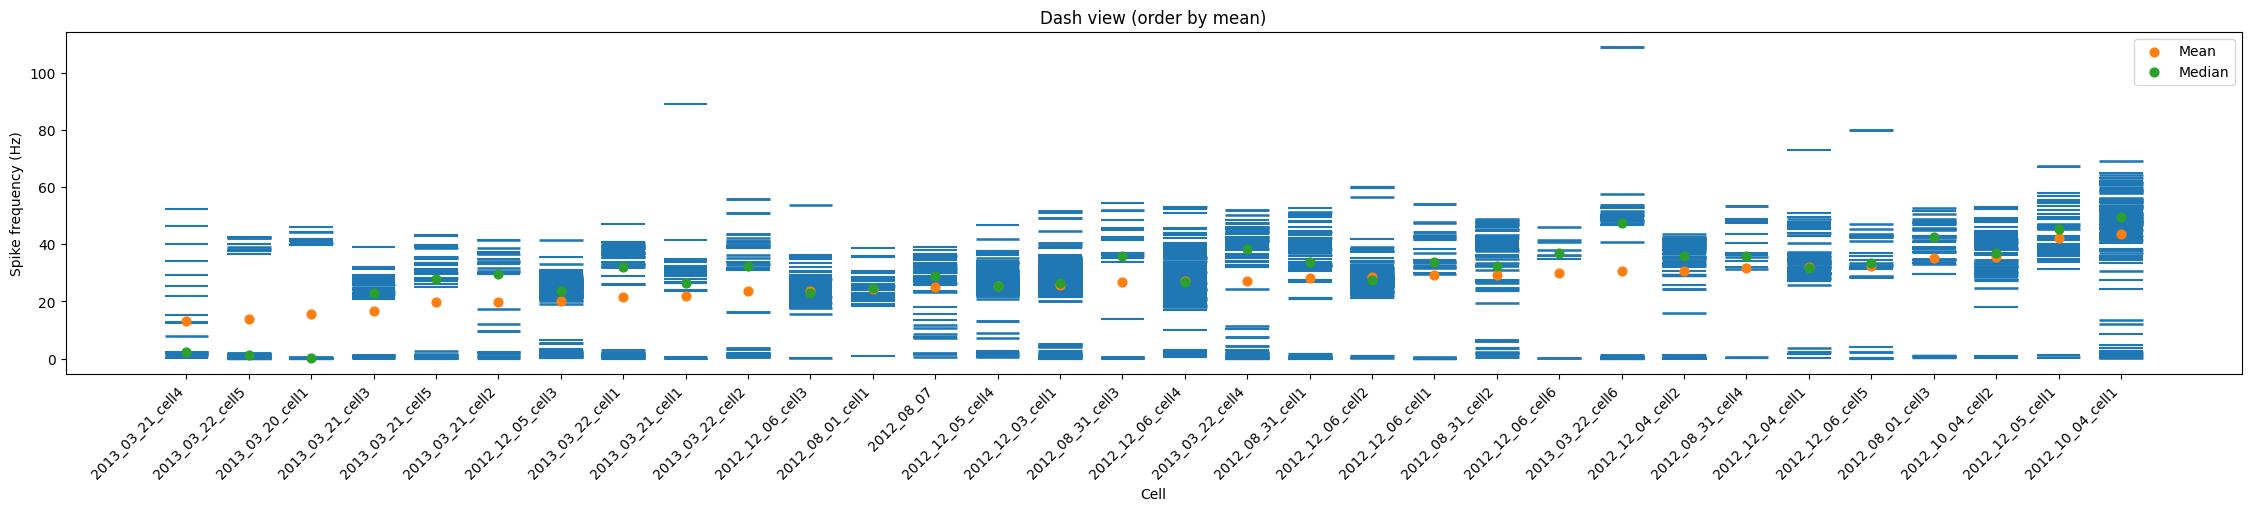

In [101]:
plot_spike_dashes(all_spikes, order_by="mean")

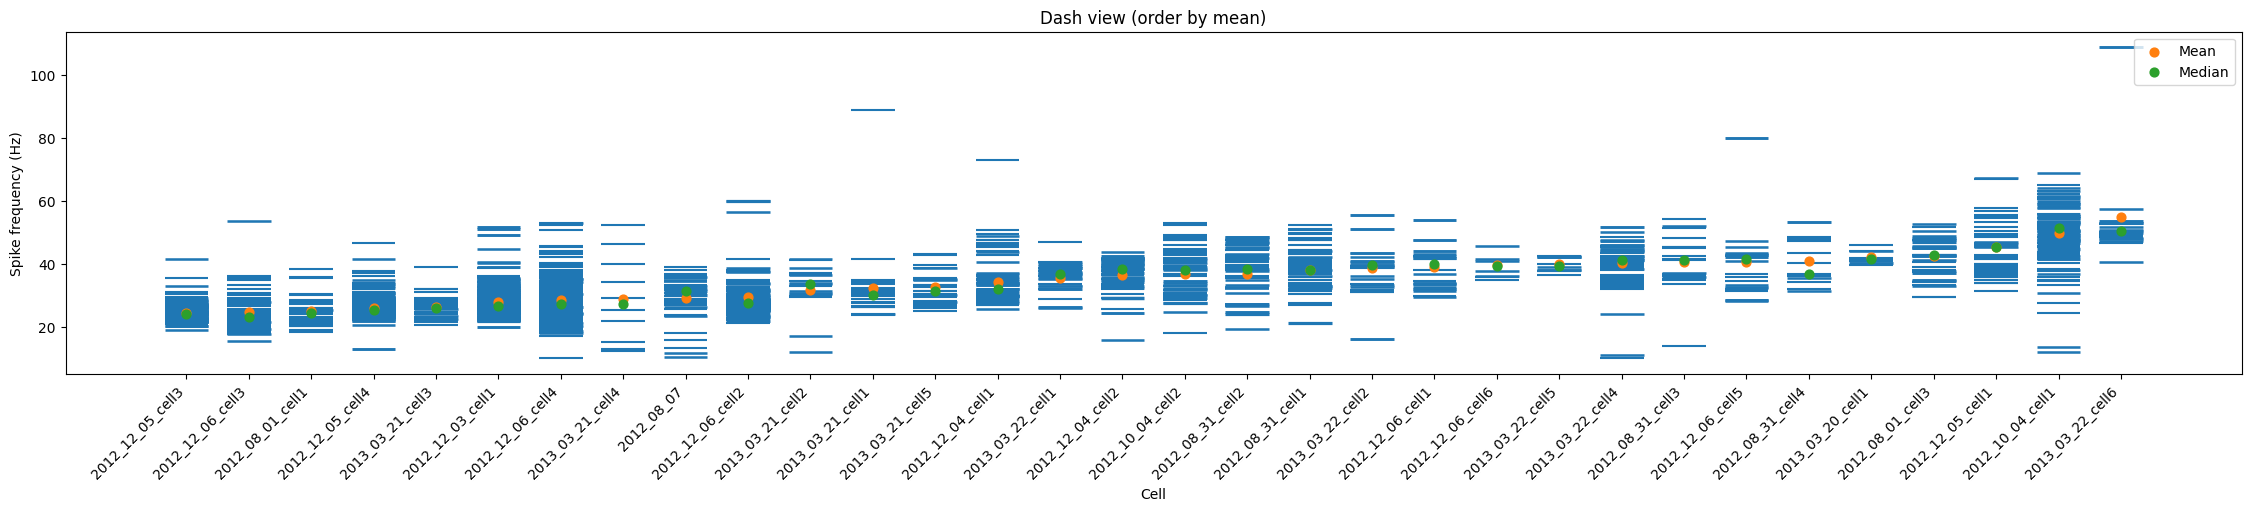

In [102]:
all_spikes_clean = clean_spikes_dataframe(all_spikes, min_freq=10)

plot_spike_dashes(all_spikes_clean, order_by="mean")

In [103]:

def summarize_spike_stats(
    all_spikes: pd.DataFrame,
    cell_col: str = "cell",
    freq_col: str = "spike_frequency",
    dropna: bool = True,
    round_decimals: int | None = None,
) -> pd.DataFrame:
    """
    Summarize spike frequencies per cell.

    Parameters
    ----------
    all_spikes : DataFrame with at least [cell_col, freq_col]
    cell_col   : column name for cell IDs (default 'cell')
    freq_col   : column name for spike frequency (Hz) (default 'spike_frequency')
    dropna     : if True, drop rows with NaN freq before aggregating
    round_decimals : optional int to round numeric outputs

    Returns
    -------
    DataFrame with columns:
      ['cell', 'mean_spike_frequency', 'median_spike_frequency',
       'min_spike_frequency', 'max_spike_frequency', 'total_spikes']
    """
    required = {cell_col, freq_col}
    missing = required - set(all_spikes.columns)
    if missing:
        raise ValueError(f"Input DataFrame missing required columns: {missing}")

    df = all_spikes[[cell_col, freq_col]].copy()
    # ensure numeric freq; coerce bad strings to NaN
    df[freq_col] = pd.to_numeric(df[freq_col], errors="coerce")
    if dropna:
        df = df.dropna(subset=[freq_col])

    out = (
        df.groupby(cell_col)[freq_col]
          .agg(
              mean_spike_frequency="mean",
              median_spike_frequency="median",
              min_spike_frequency="min",
              max_spike_frequency="max",
              total_spikes="count",   # counts non-NaN
          )
          .reset_index()
          .rename(columns={cell_col: "cell"})
    )

    if round_decimals is not None:
        num_cols = ["mean_spike_frequency", "median_spike_frequency",
                    "min_spike_frequency", "max_spike_frequency"]
        out[num_cols] = out[num_cols].round(round_decimals)

    return out

stats = summarize_spike_stats(all_spikes, round_decimals=2)
print(stats.head())
# assuming you already made: stats = summarize_spike_stats(all_spikes, round_decimals=2)

import os
out_path = os.path.join(parent_folder_path, "spike_stats.csv")  # or any folder you want
stats.to_csv(out_path, index=False)  # no extra index column
print(f"Saved: {out_path}")



               cell  mean_spike_frequency  median_spike_frequency  \
0  2012_08_01_cell1                 24.39                   24.50   
1  2012_08_01_cell3                 35.14                   42.64   
2        2012_08_07                 24.88                   28.92   
3  2012_08_31_cell1                 28.10                   33.90   
4  2012_08_31_cell2                 29.35                   32.47   

   min_spike_frequency  max_spike_frequency  total_spikes  
0                 0.88                38.55            42  
1                 0.60                52.69            79  
2                 0.38                38.93            81  
3                 0.07                52.55            93  
4                 0.39                48.71            97  
Saved: /Users/Haley/Desktop/spike_stats.csv


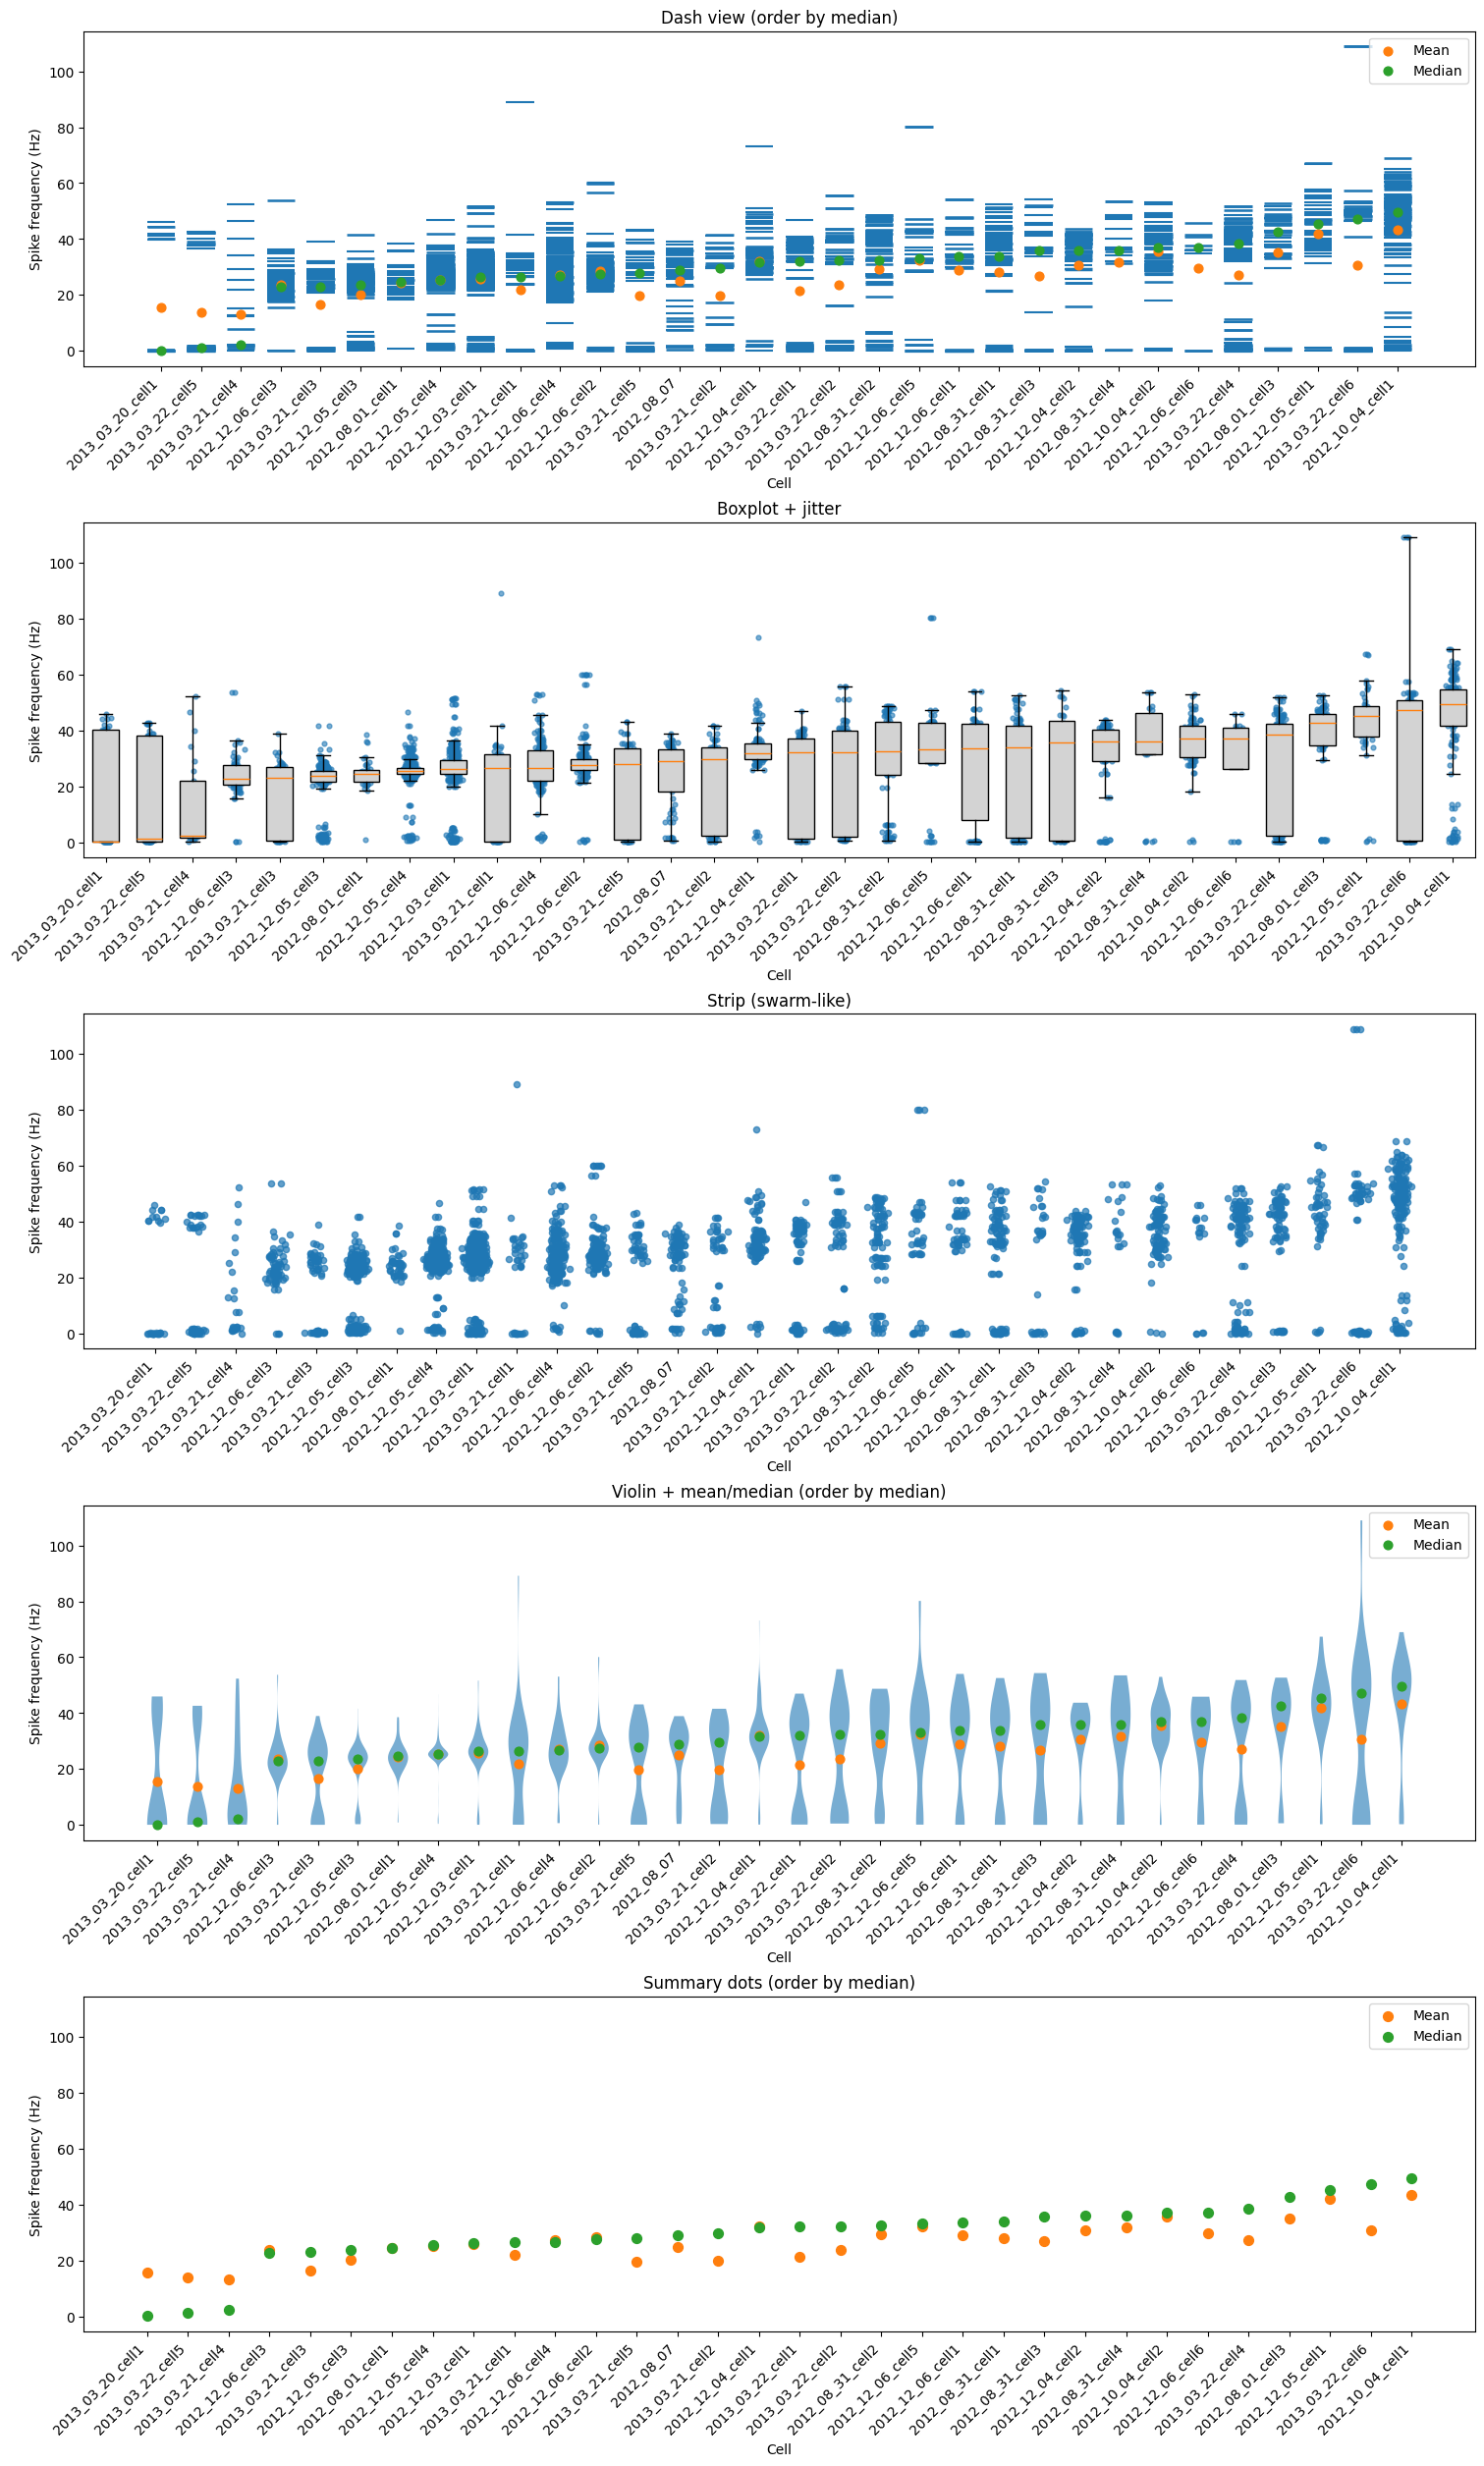

In [104]:
# Stacked 1×5 grid, order by median
plot_all_views_grid(all_spikes, order_by="median")


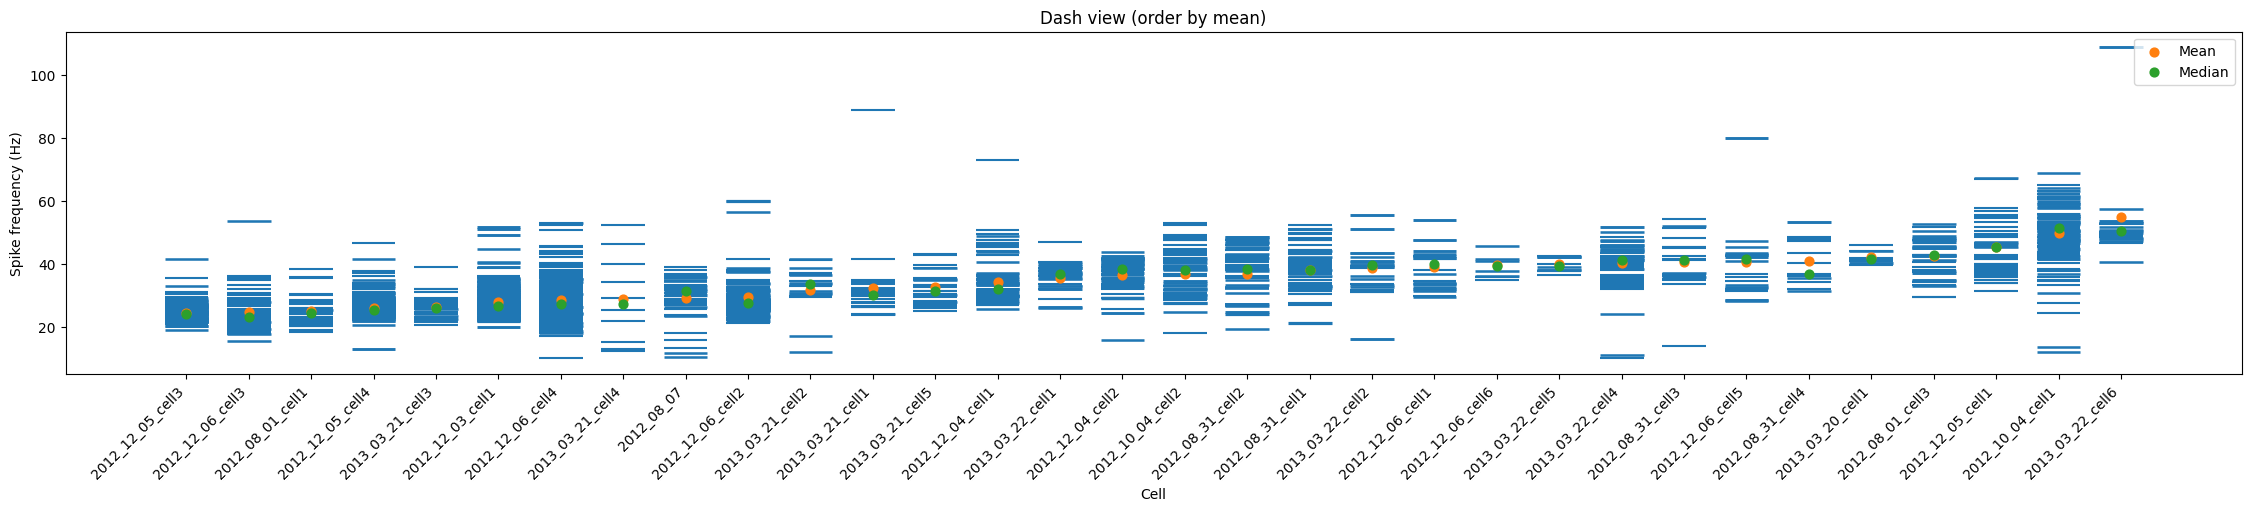

/Users/Haley/Desktop/murray-neuroscience-lab/Cleaned, updated files from Spring/cellattachedspikes.py:691: UserWarning: The figure layout has changed to tight
  


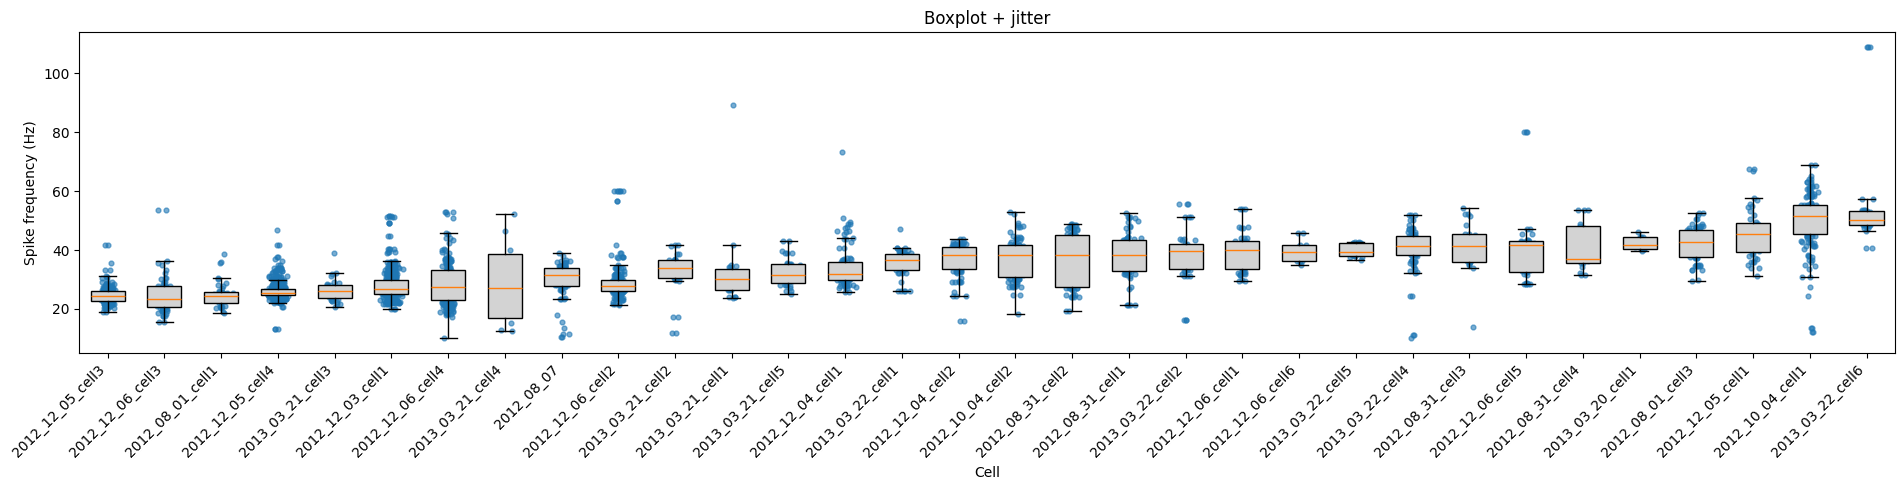

/Users/Haley/Desktop/murray-neuroscience-lab/Cleaned, updated files from Spring/cellattachedspikes.py:718: UserWarning: The figure layout has changed to tight
  for pc in parts["bodies"]:


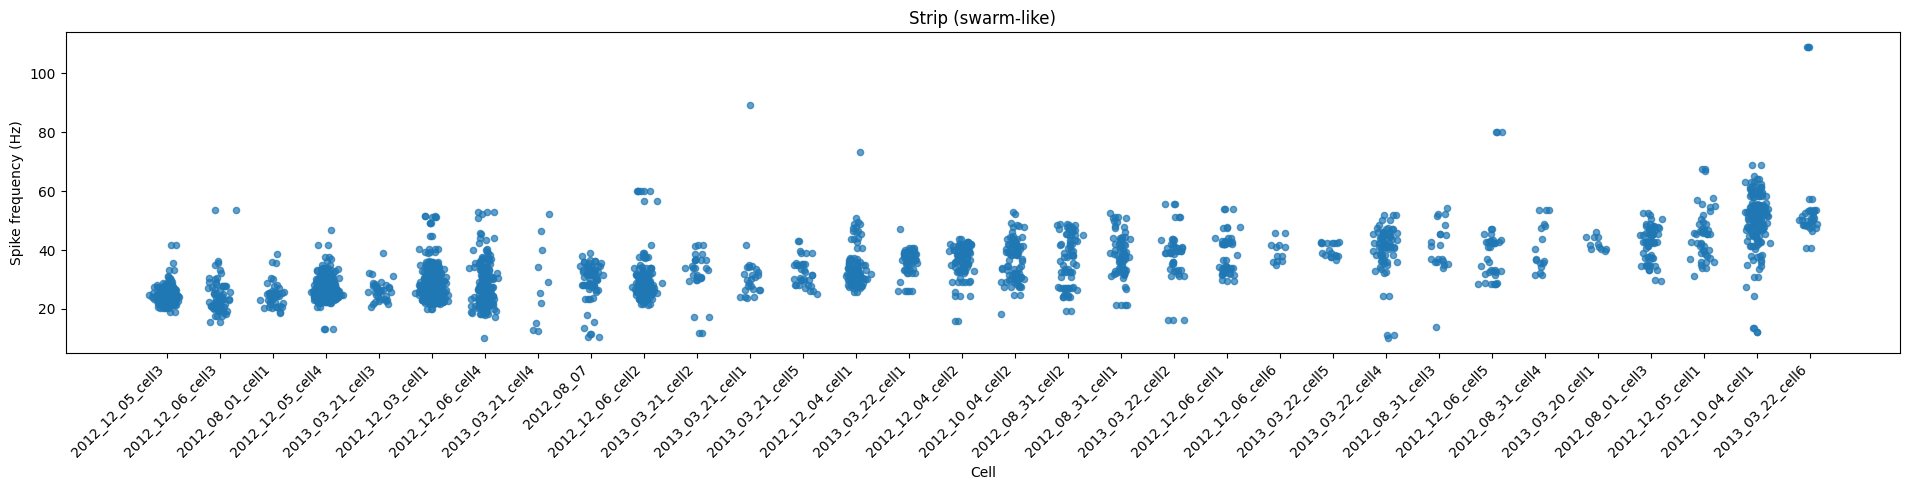

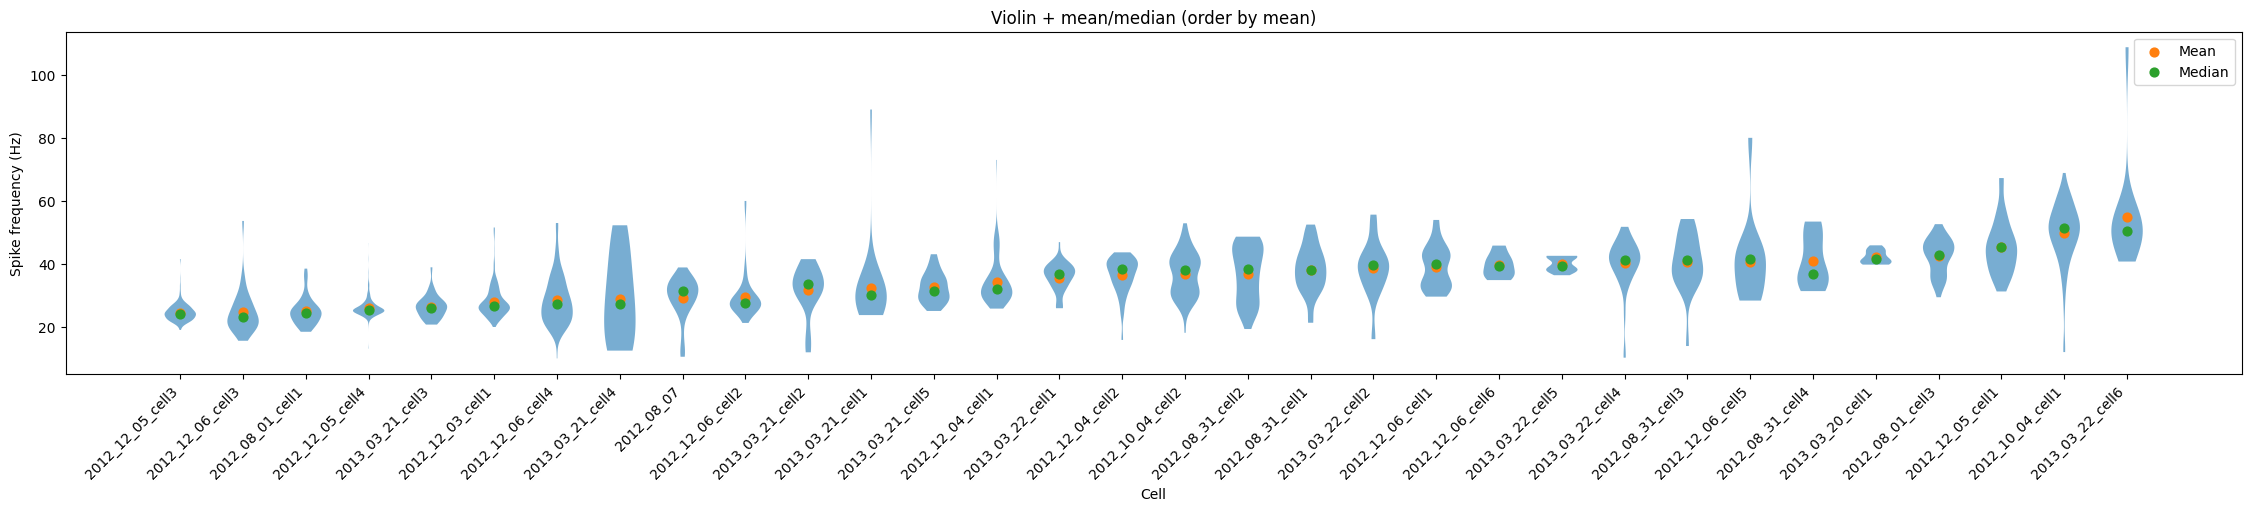

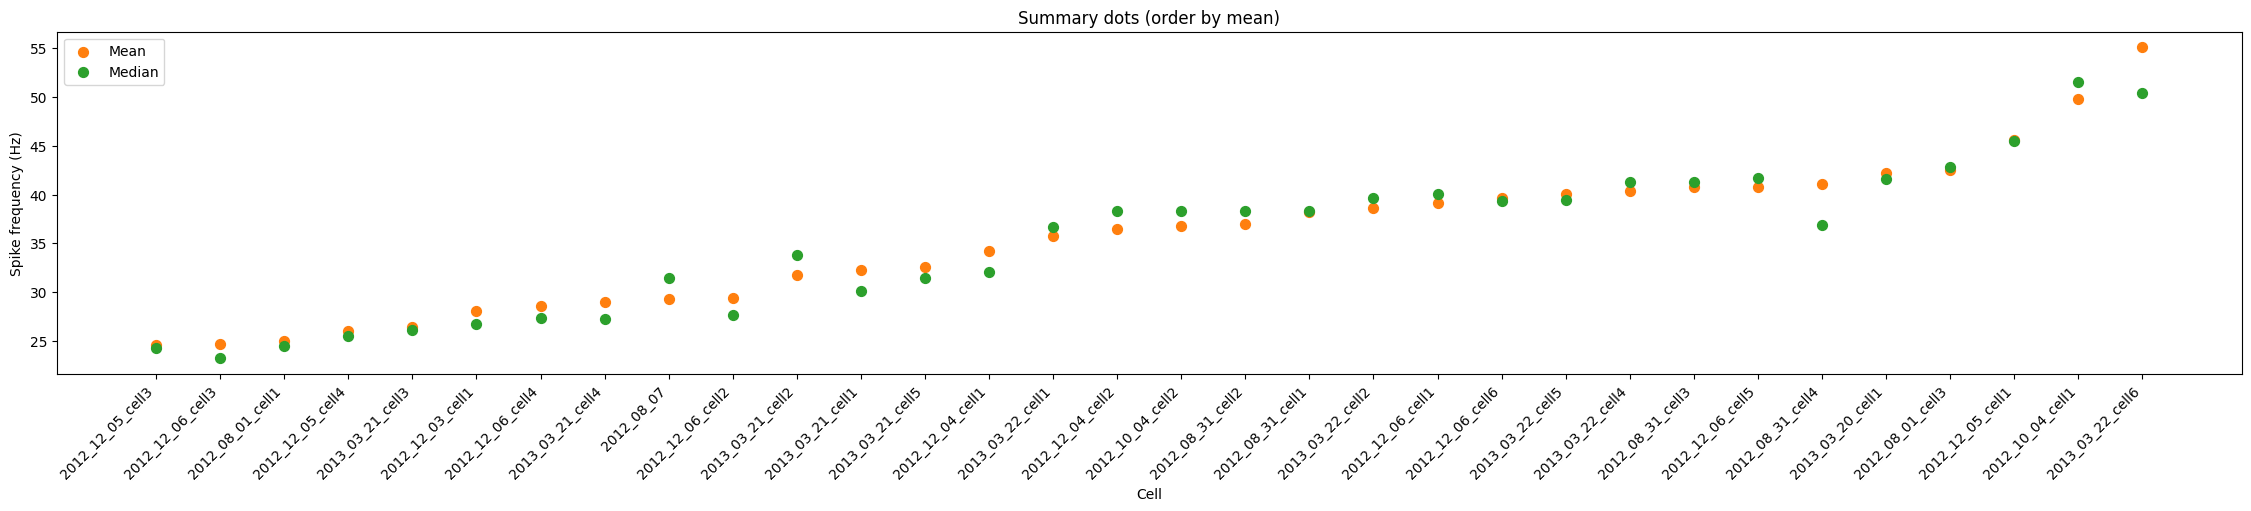

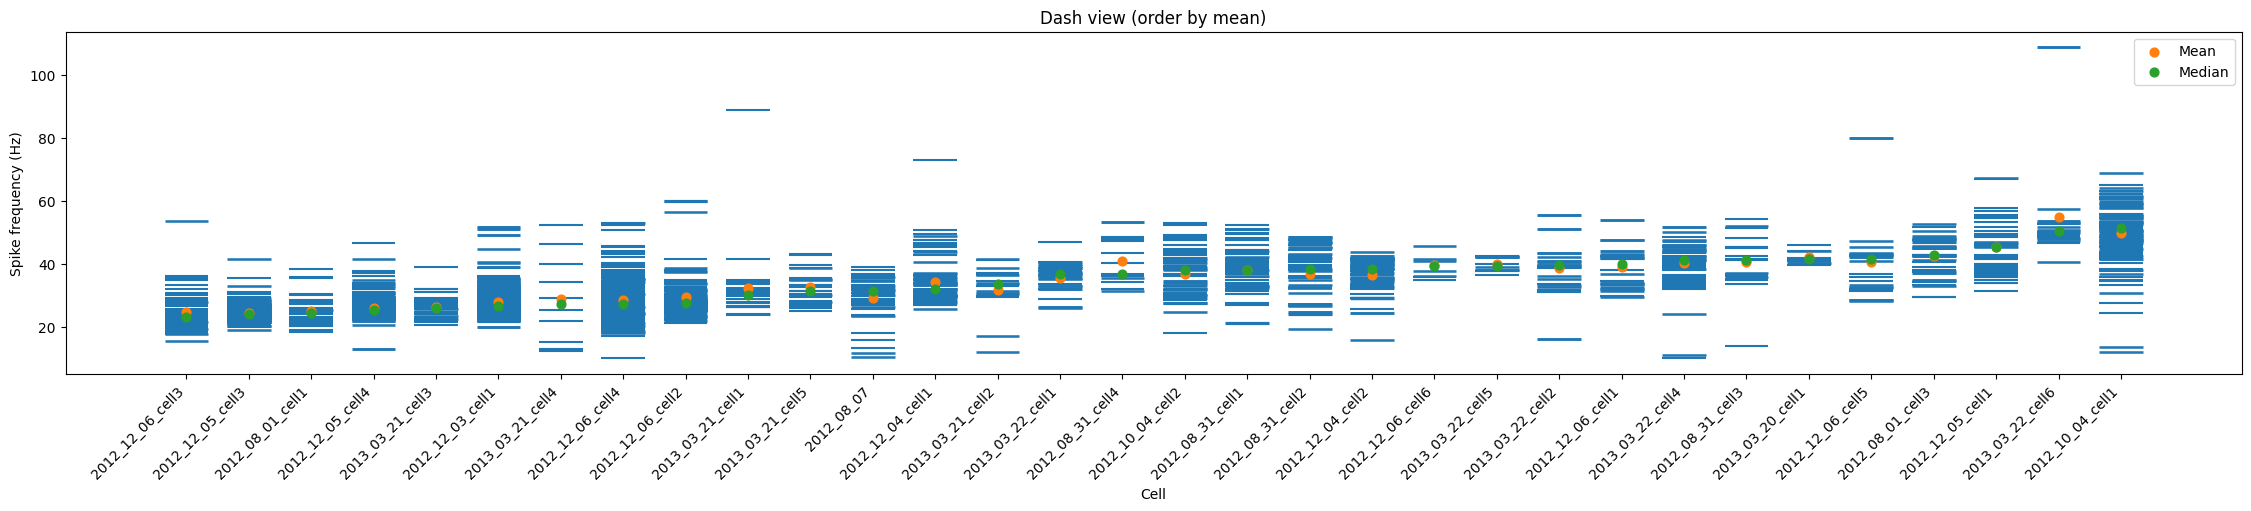

/Users/Haley/Desktop/murray-neuroscience-lab/Cleaned, updated files from Spring/cellattachedspikes.py:691: UserWarning: The figure layout has changed to tight
  


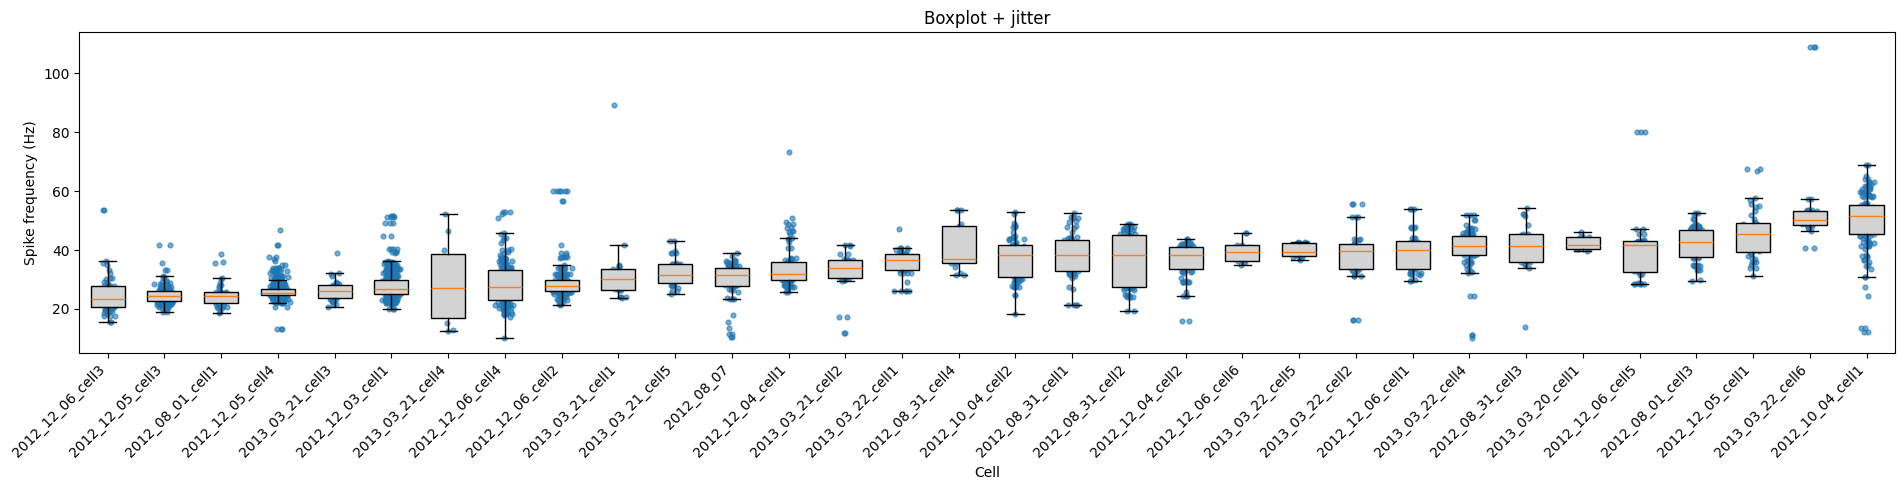

/Users/Haley/Desktop/murray-neuroscience-lab/Cleaned, updated files from Spring/cellattachedspikes.py:718: UserWarning: The figure layout has changed to tight
  for pc in parts["bodies"]:


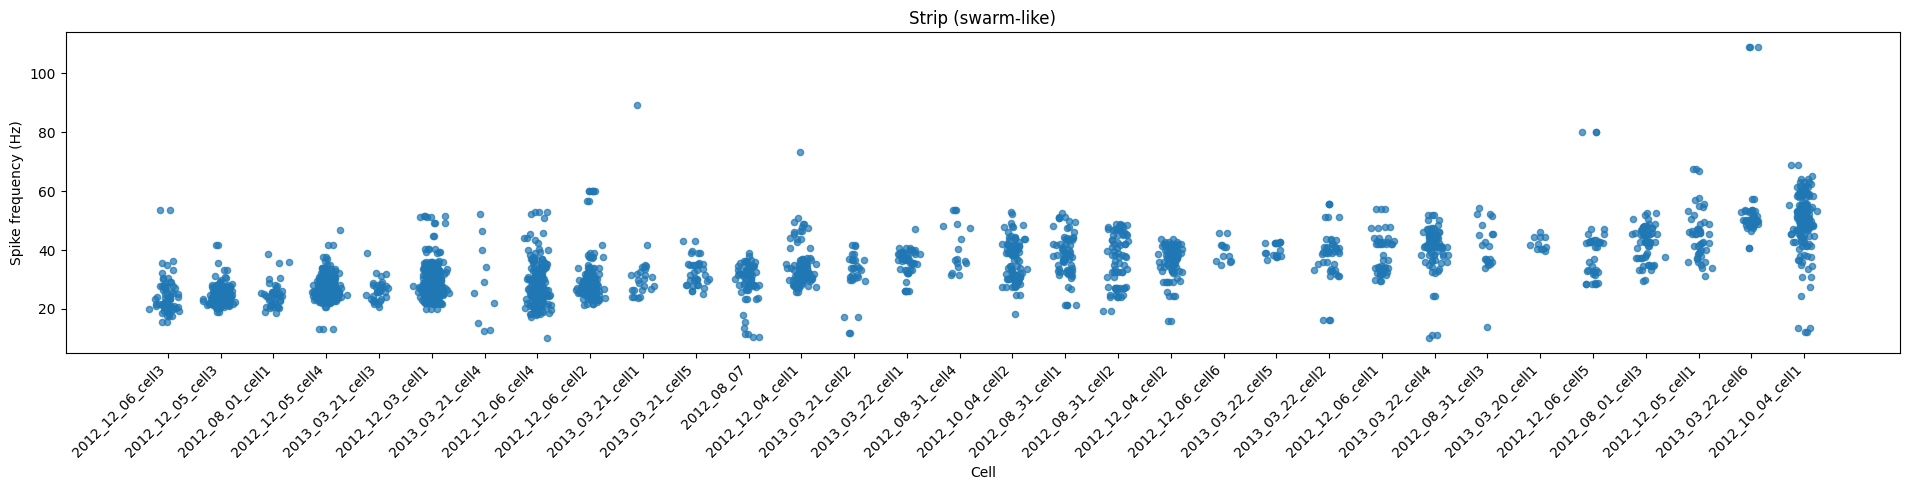

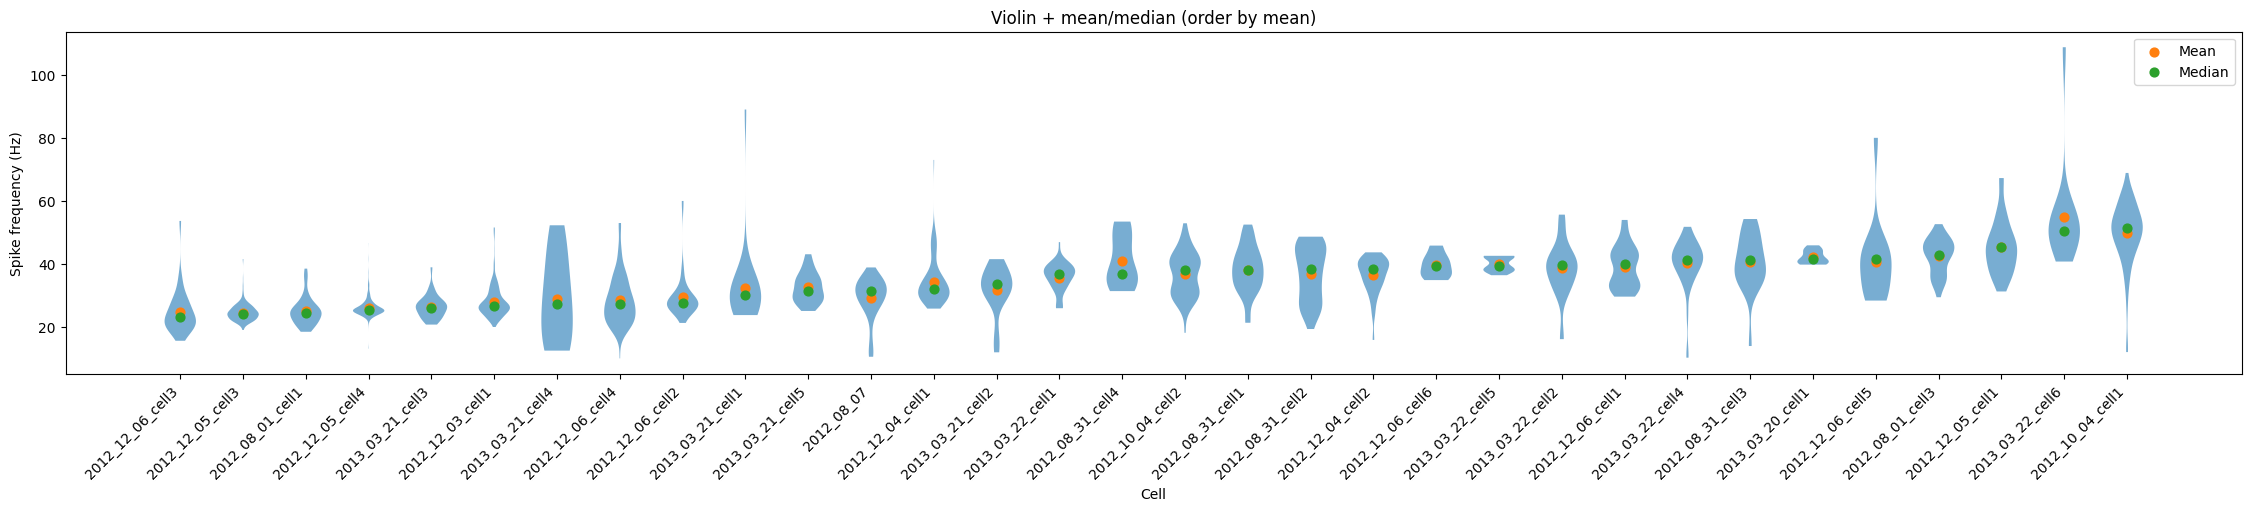

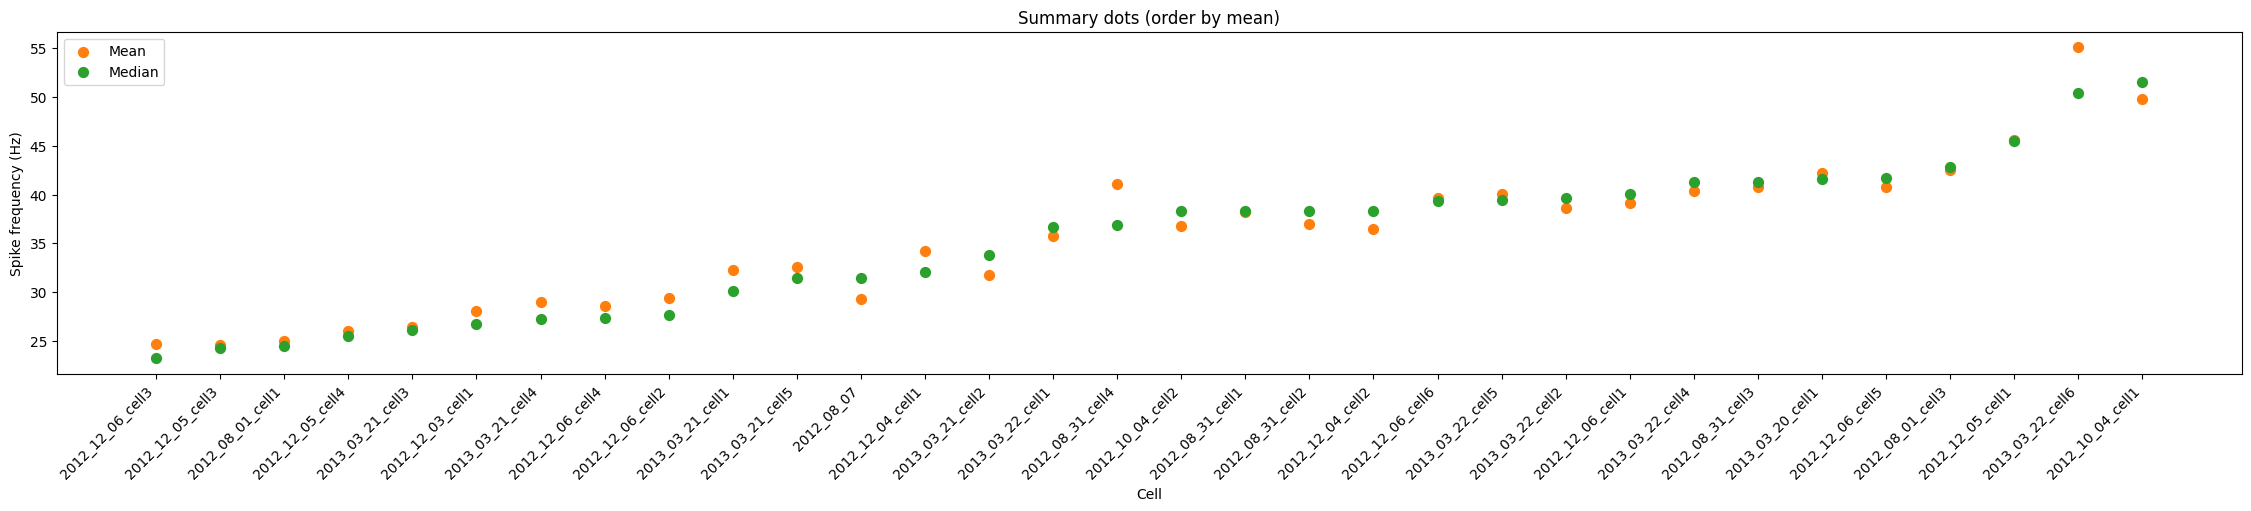

In [105]:
plot_all_views(all_spikes_clean, order_by="mean")

# Positional (since order_by is 2nd arg)
plot_all_views(all_spikes_clean, "median")



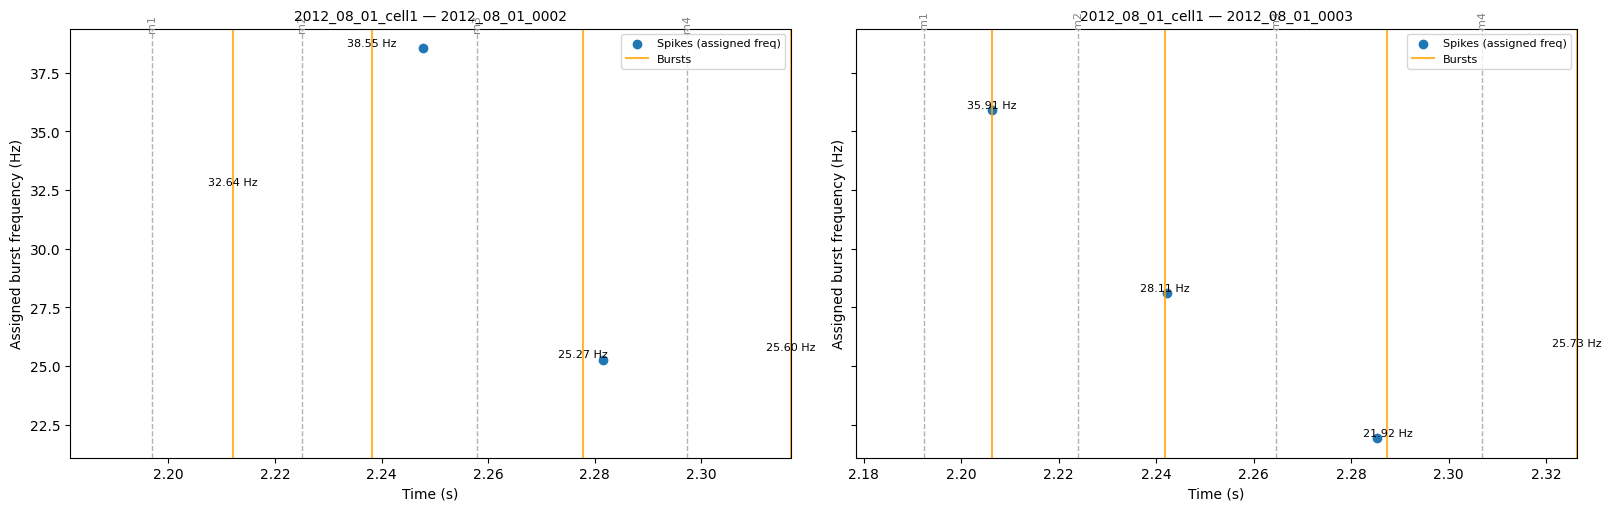

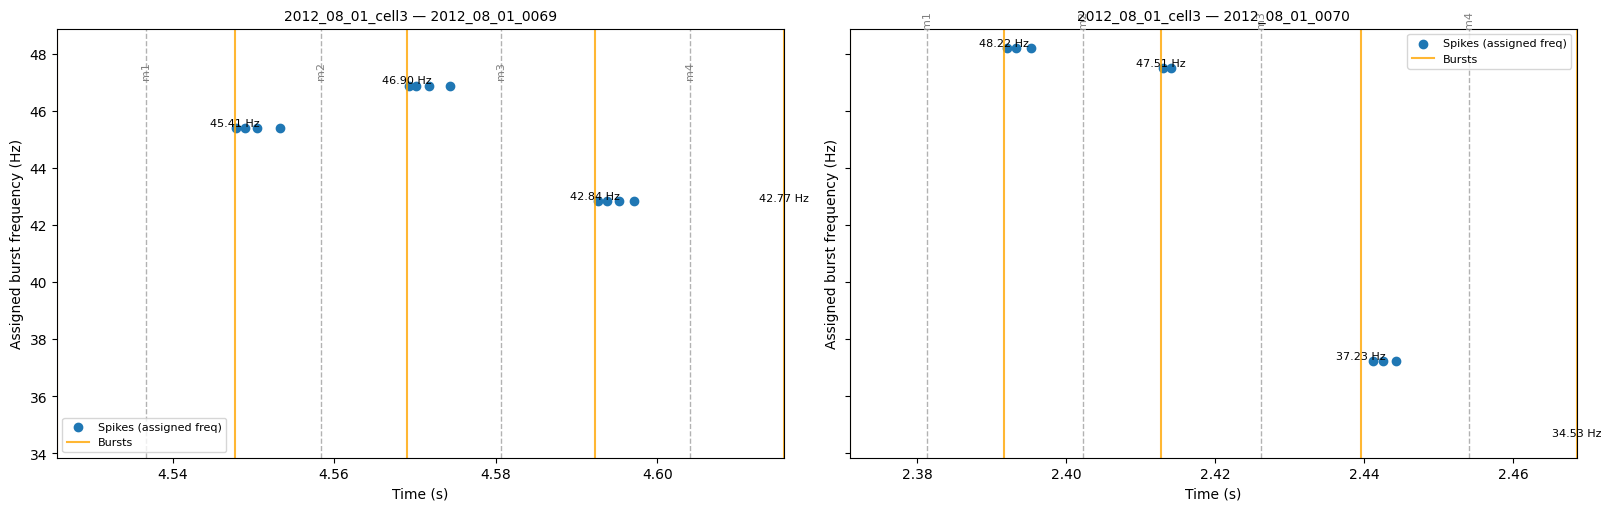

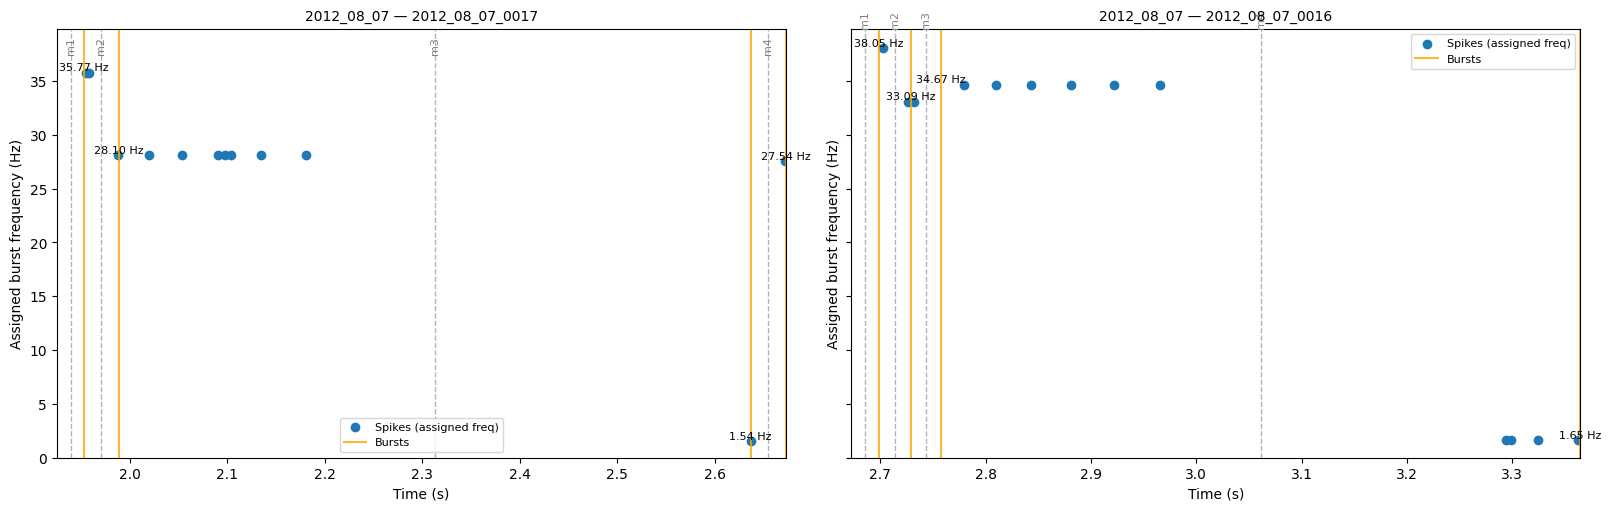

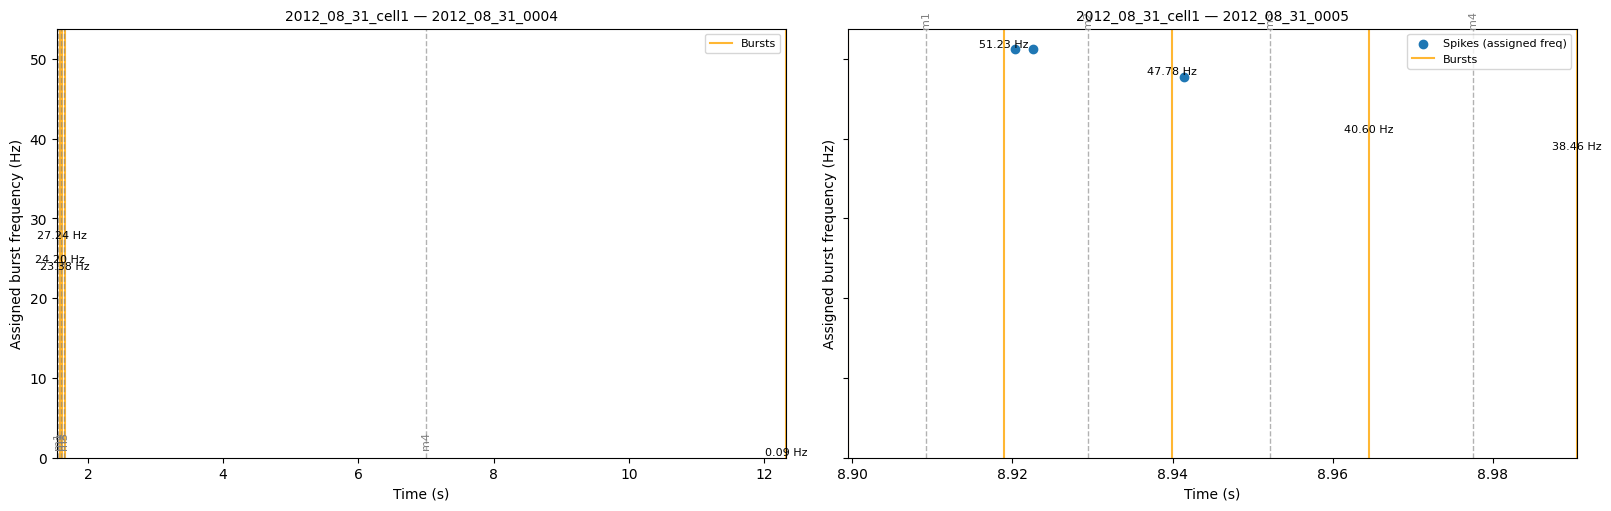

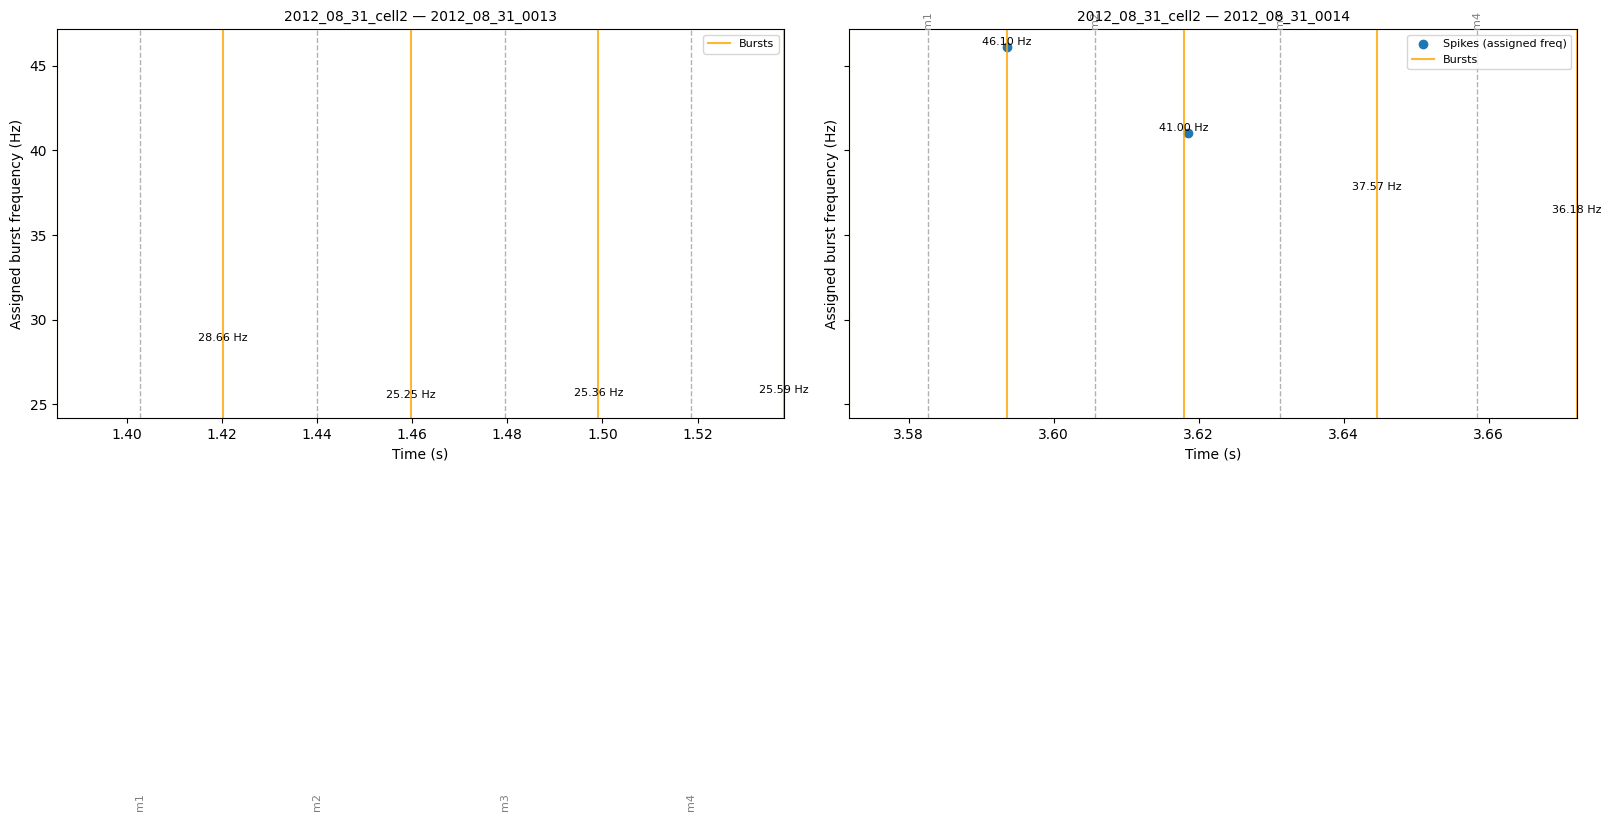

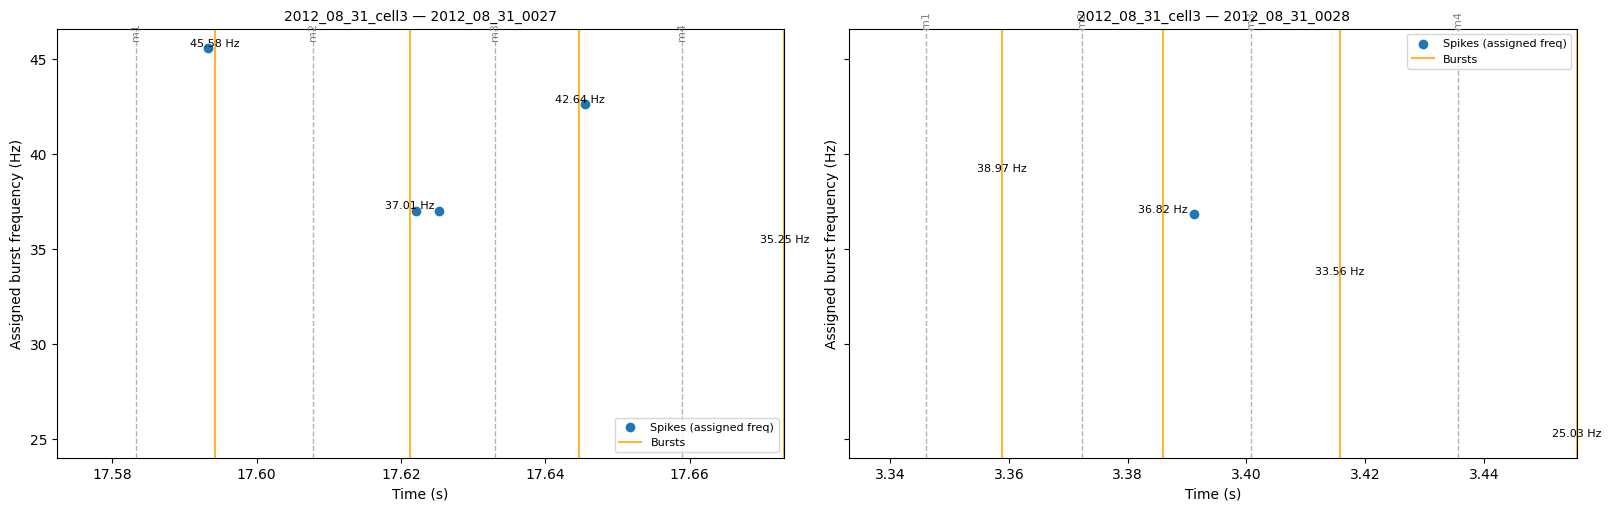

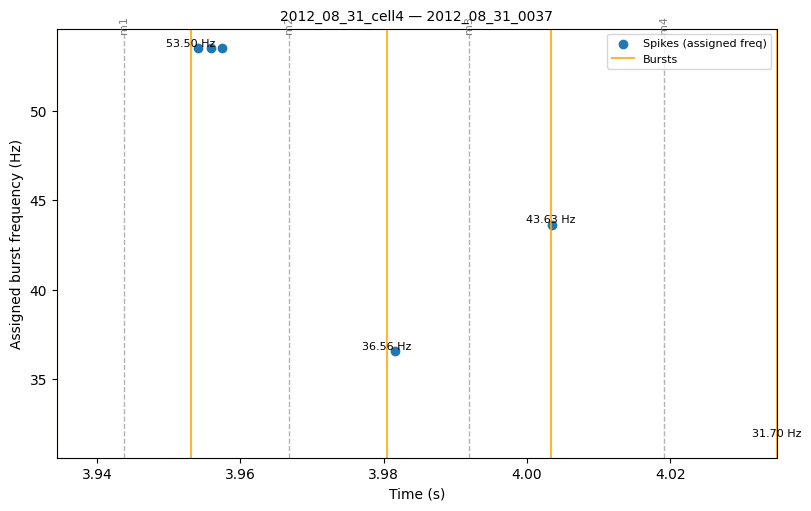

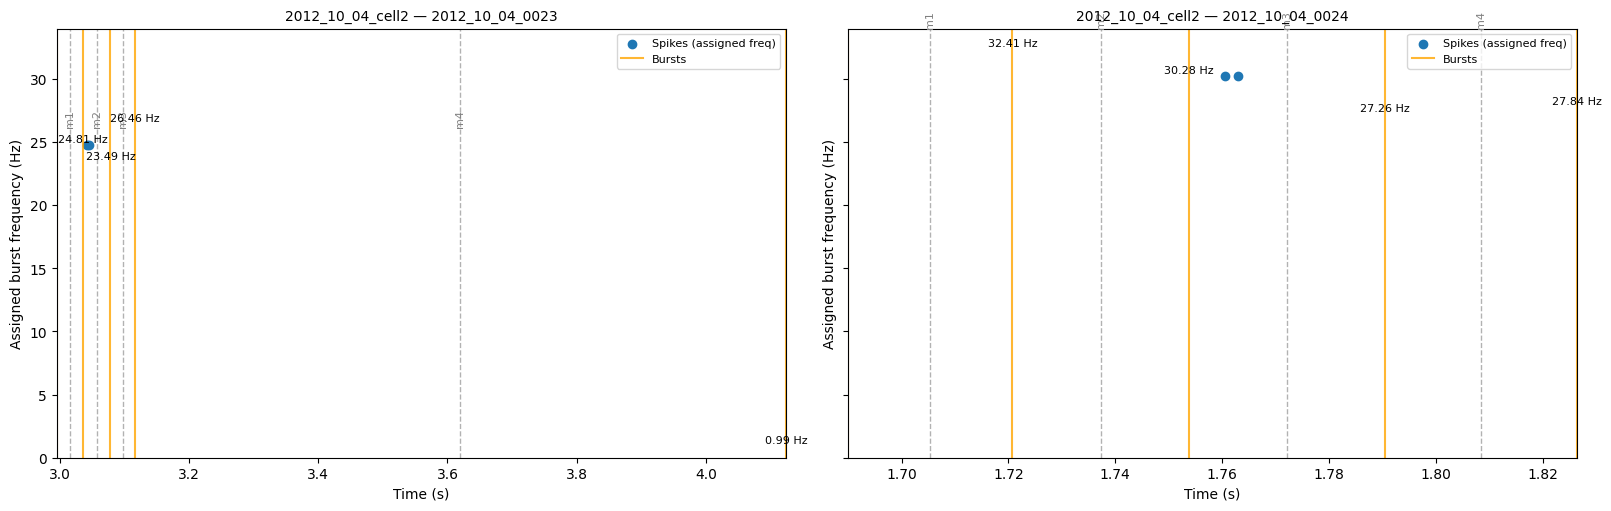

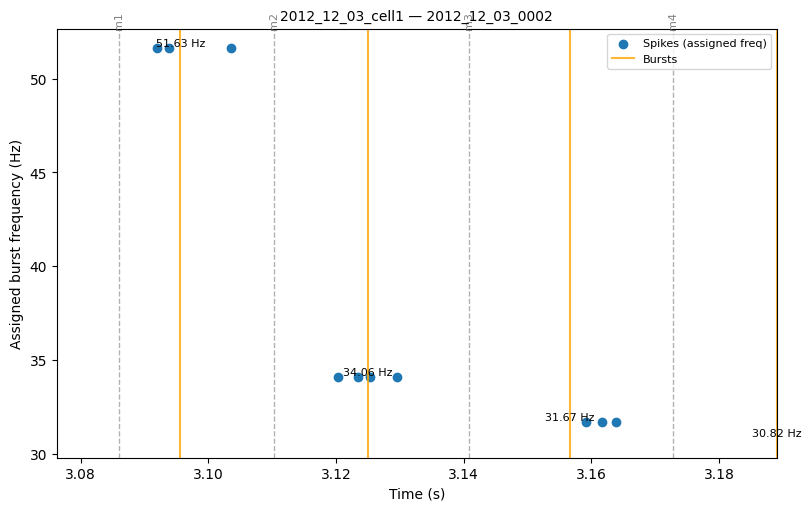

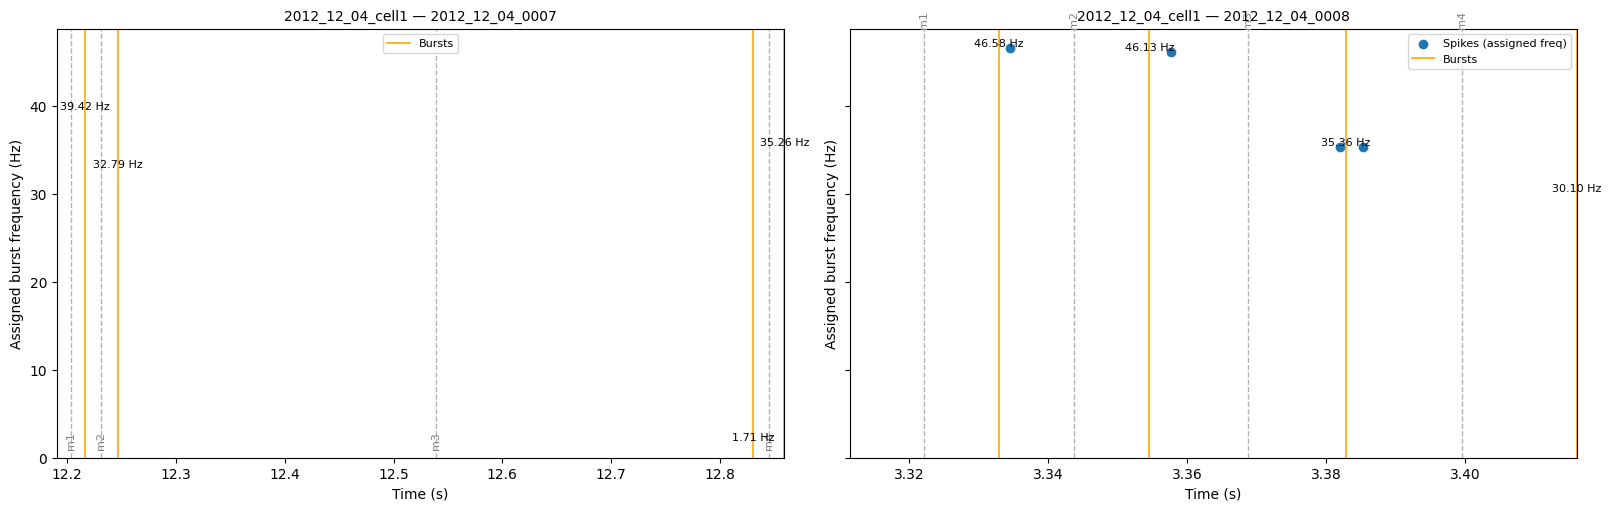

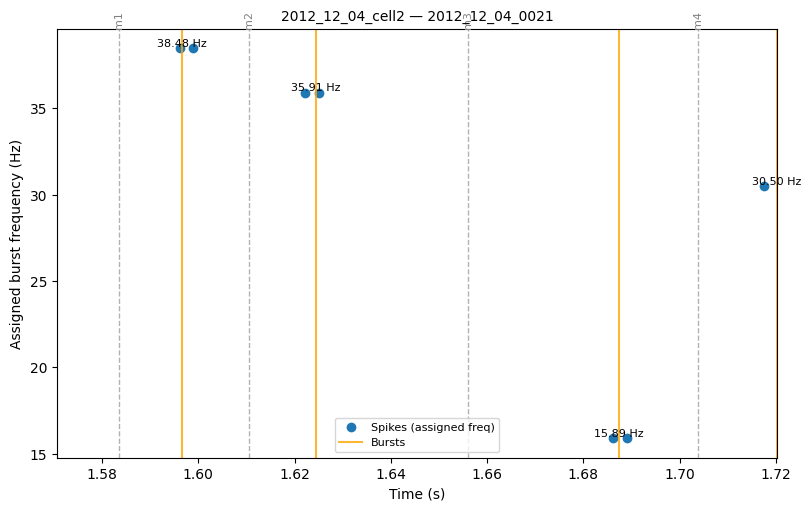

/Users/Haley/Desktop/murray-neuroscience-lab/neuro-venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or Axes decorations smaller.
  fig.canvas.print_figure(bytes_io, **kw)


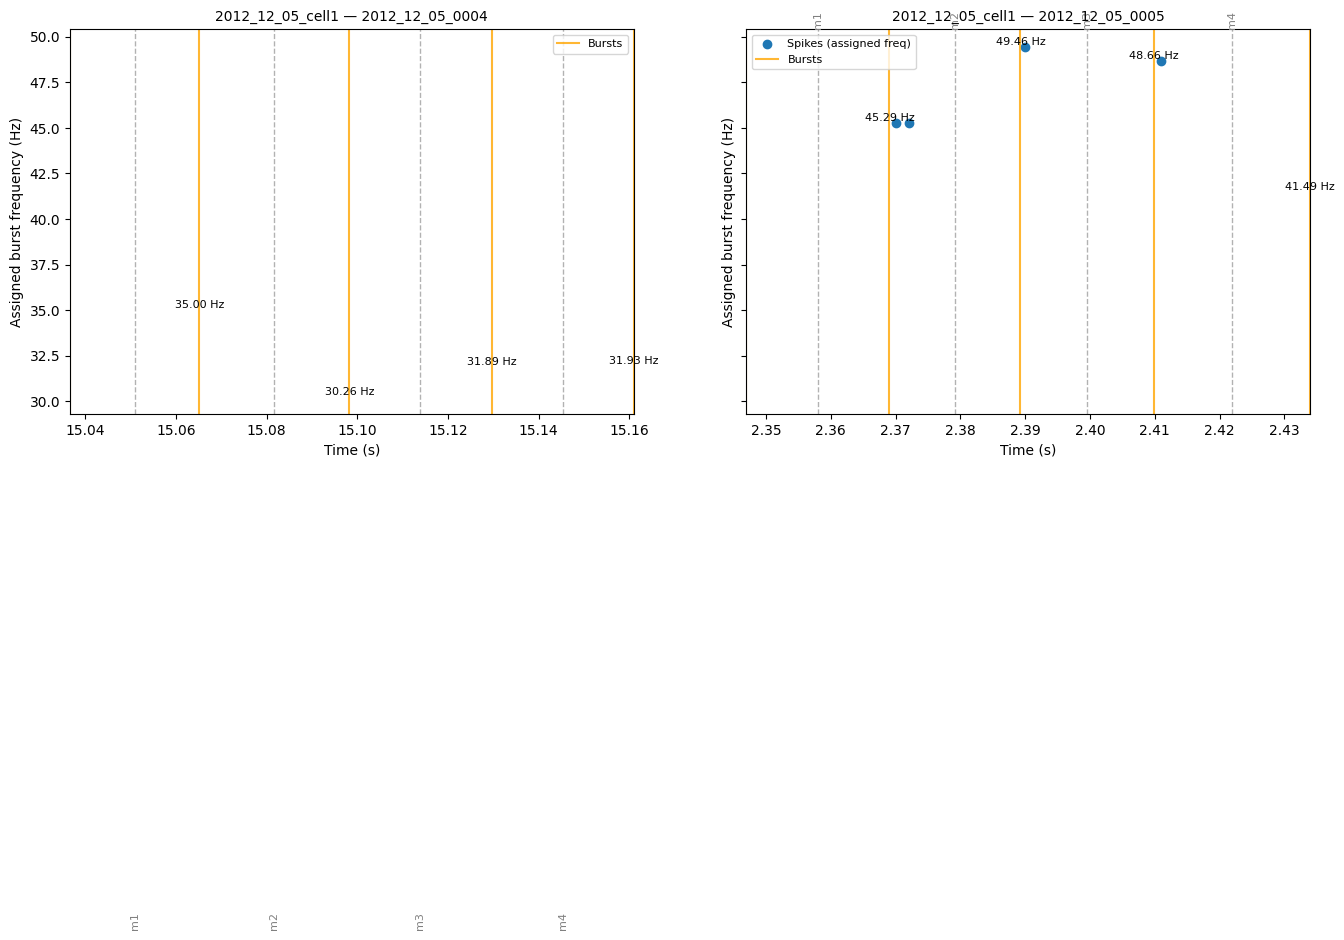

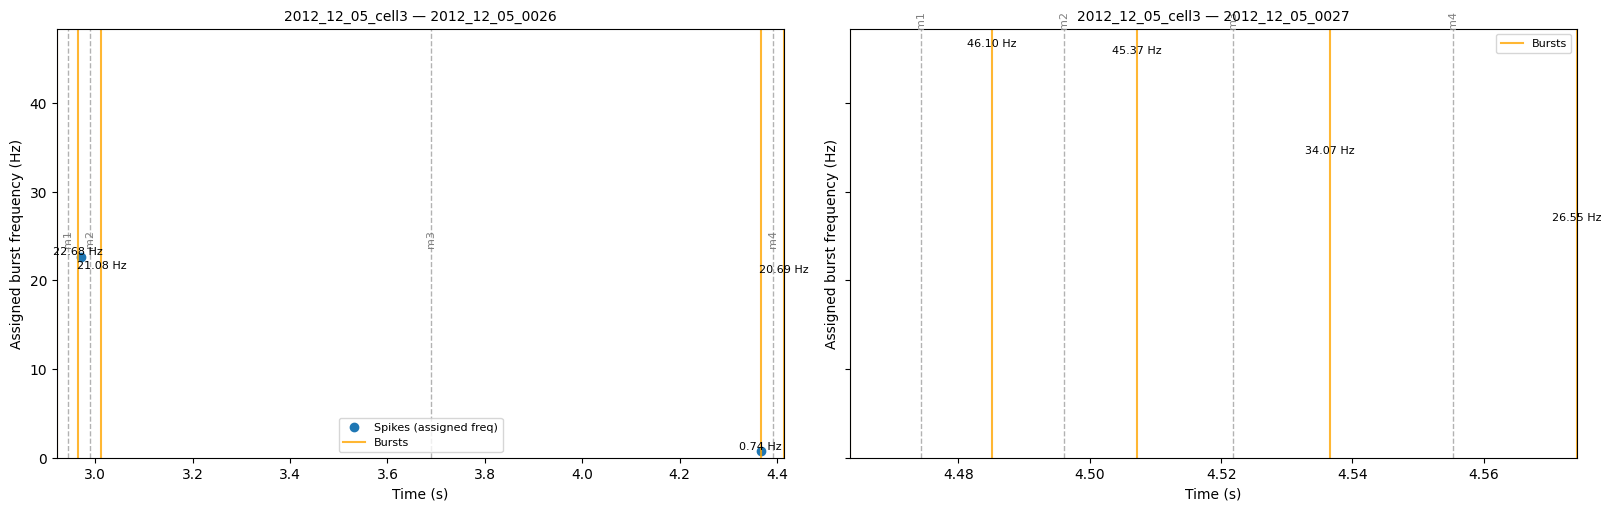

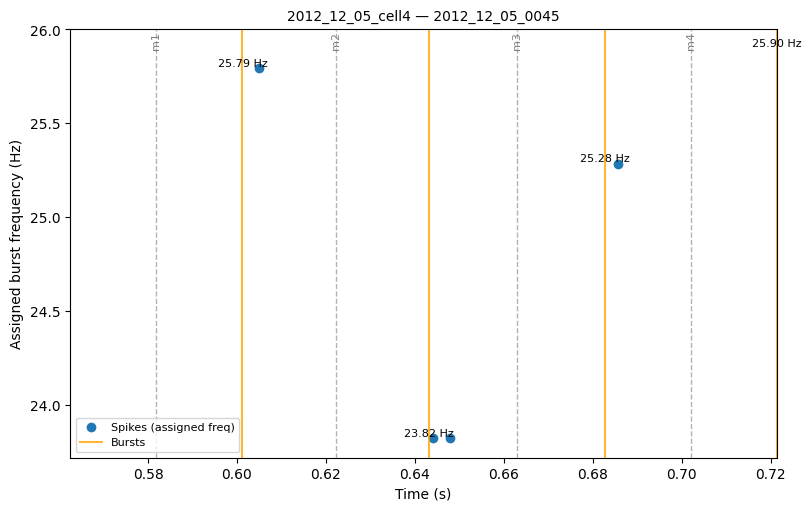

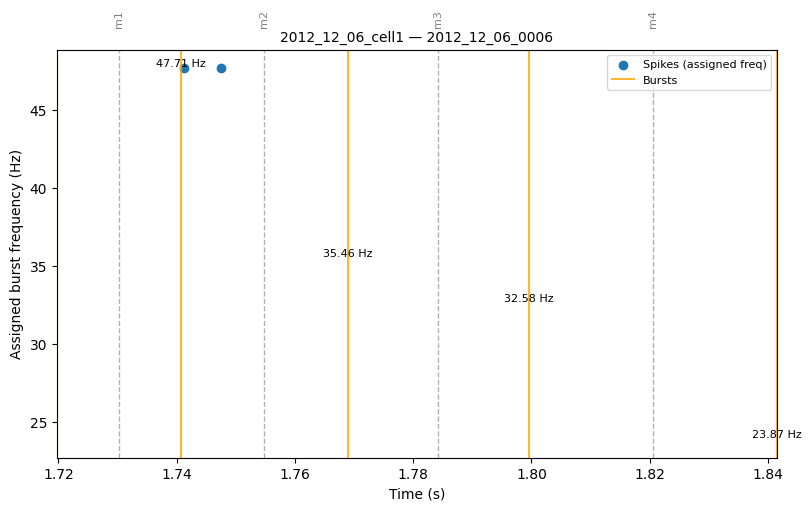

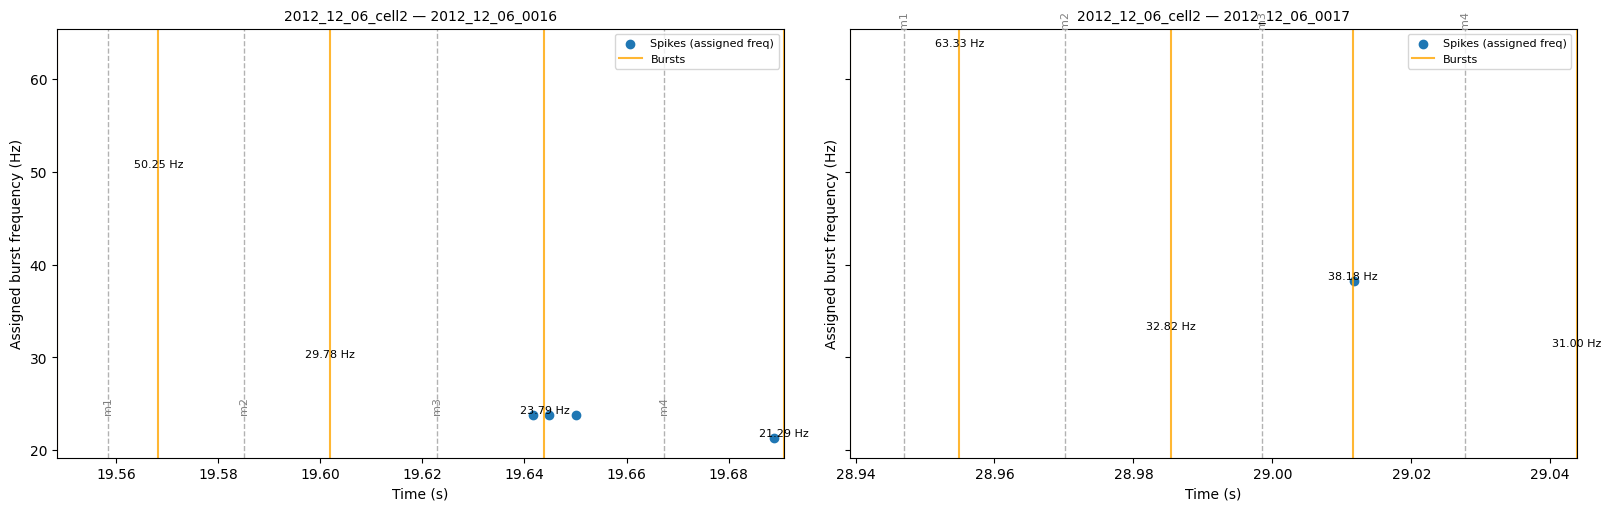

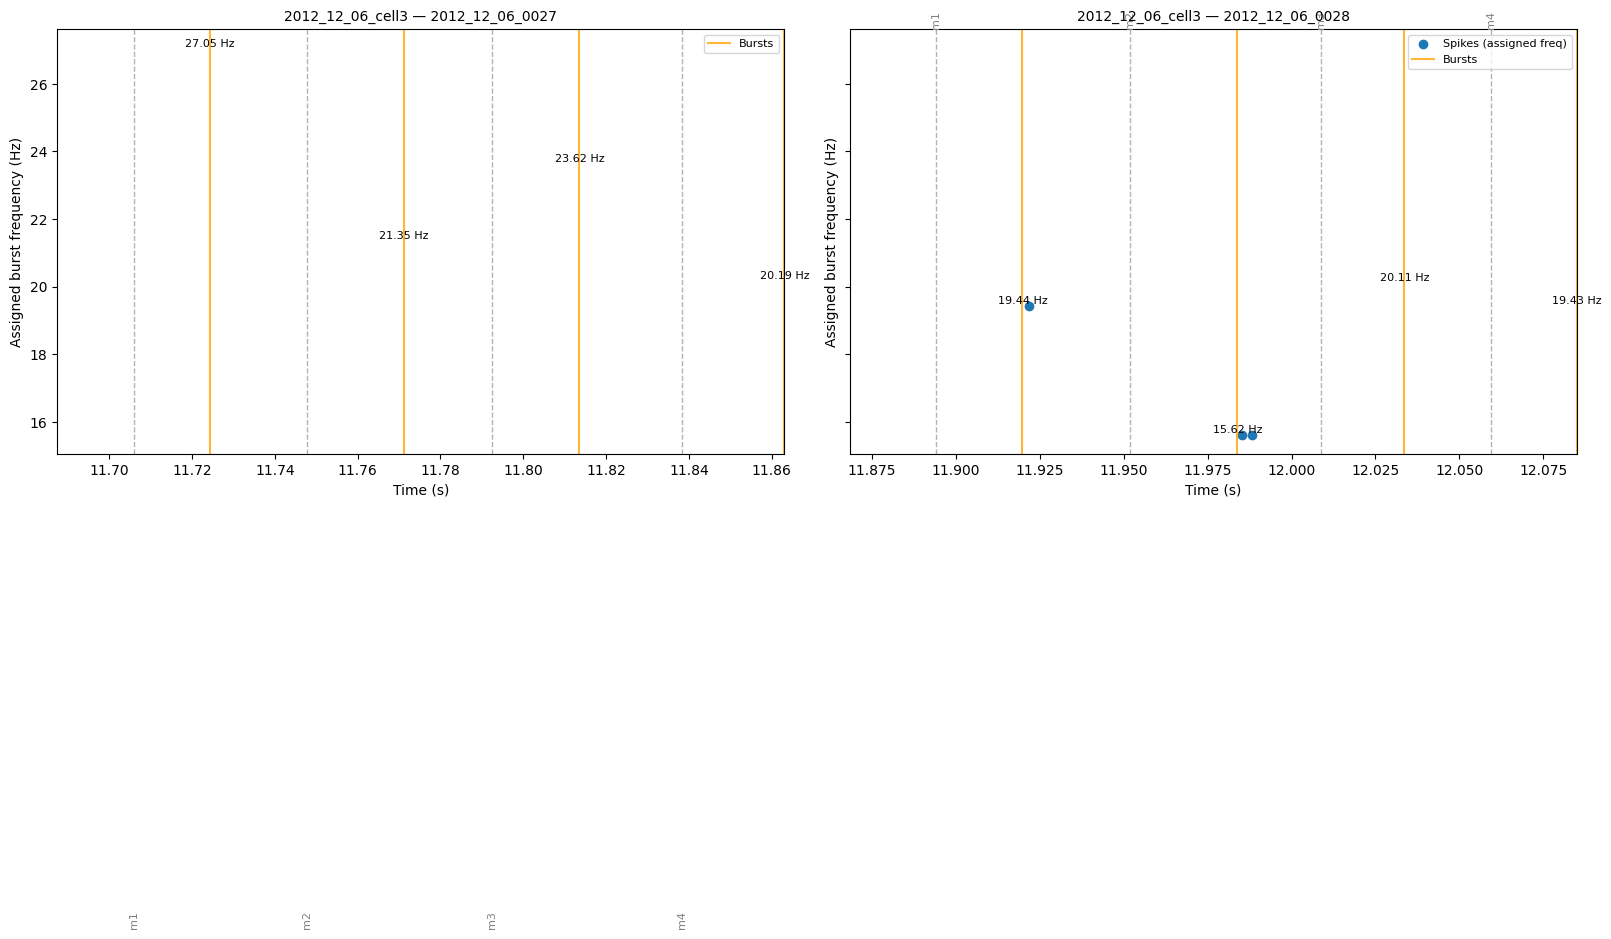

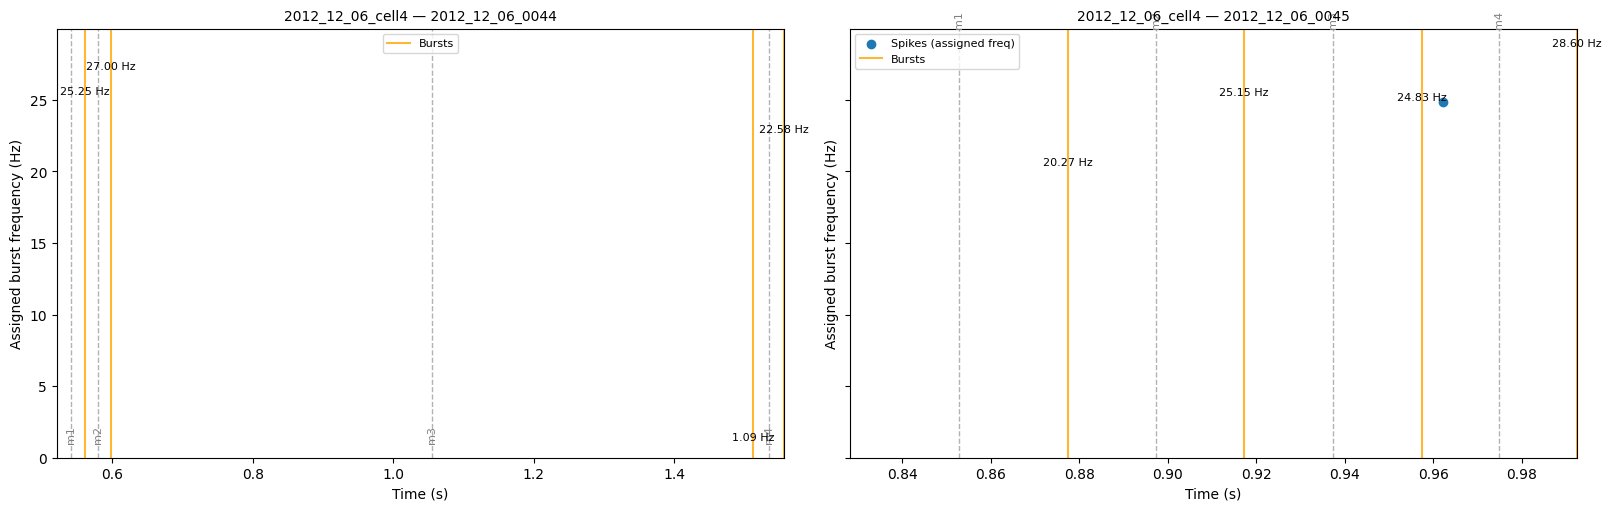

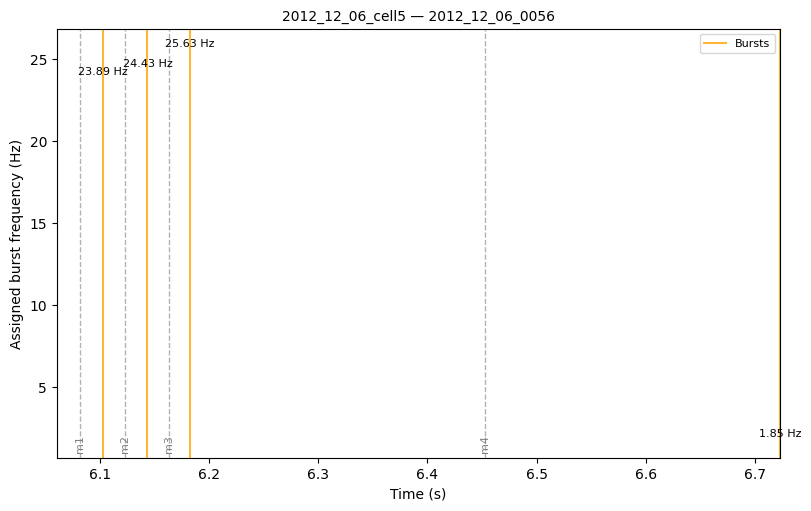

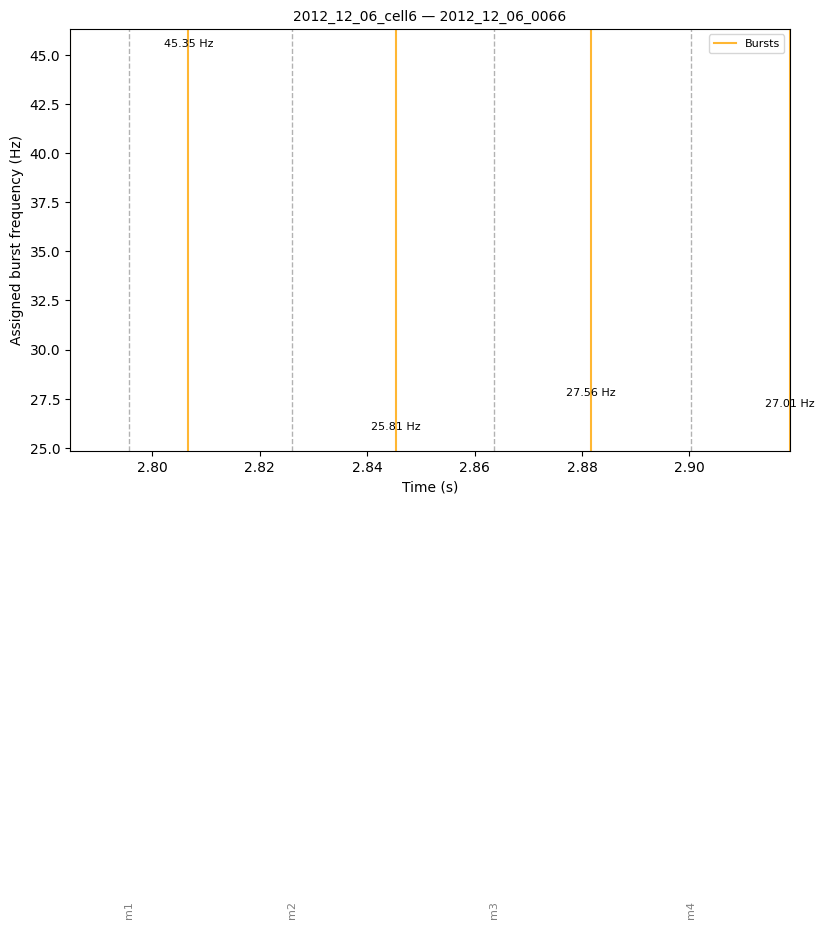

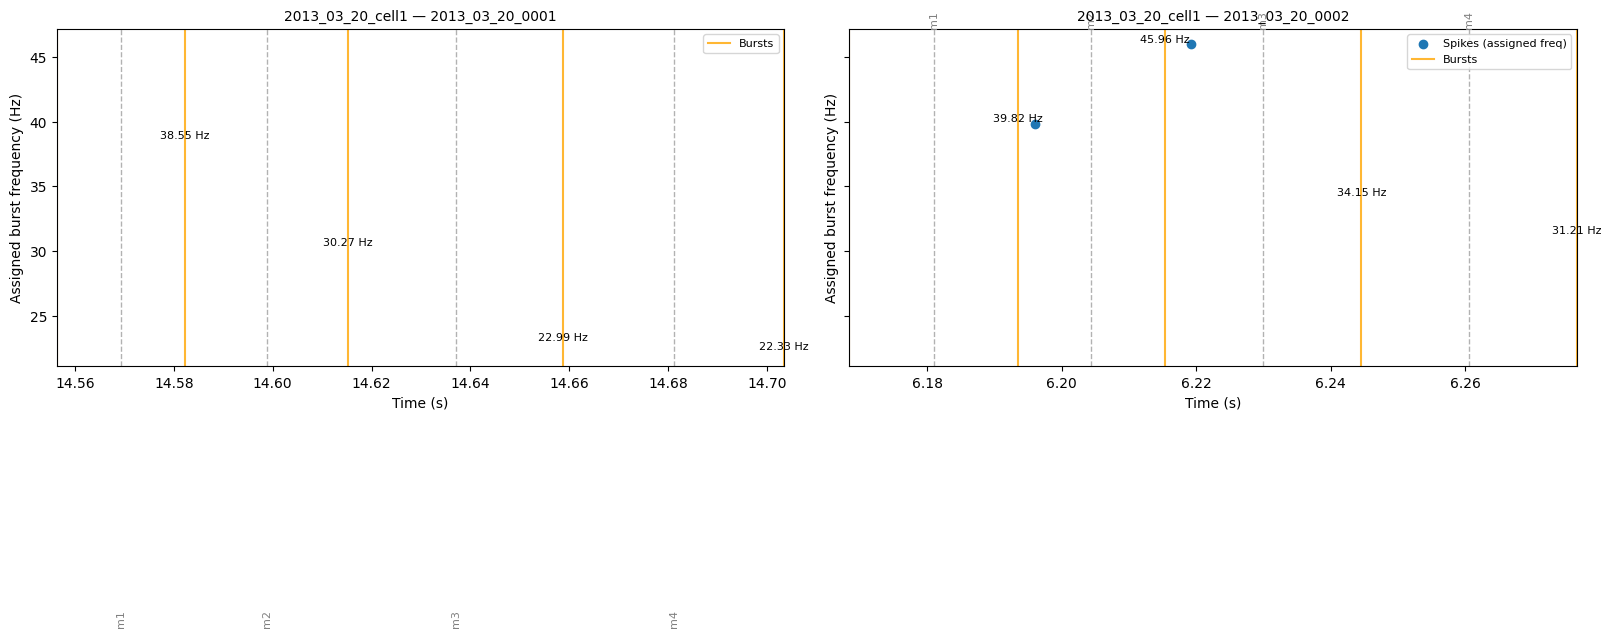

/Users/Haley/Desktop/murray-neuroscience-lab/neuro-venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or Axes decorations smaller.
  fig.canvas.print_figure(bytes_io, **kw)


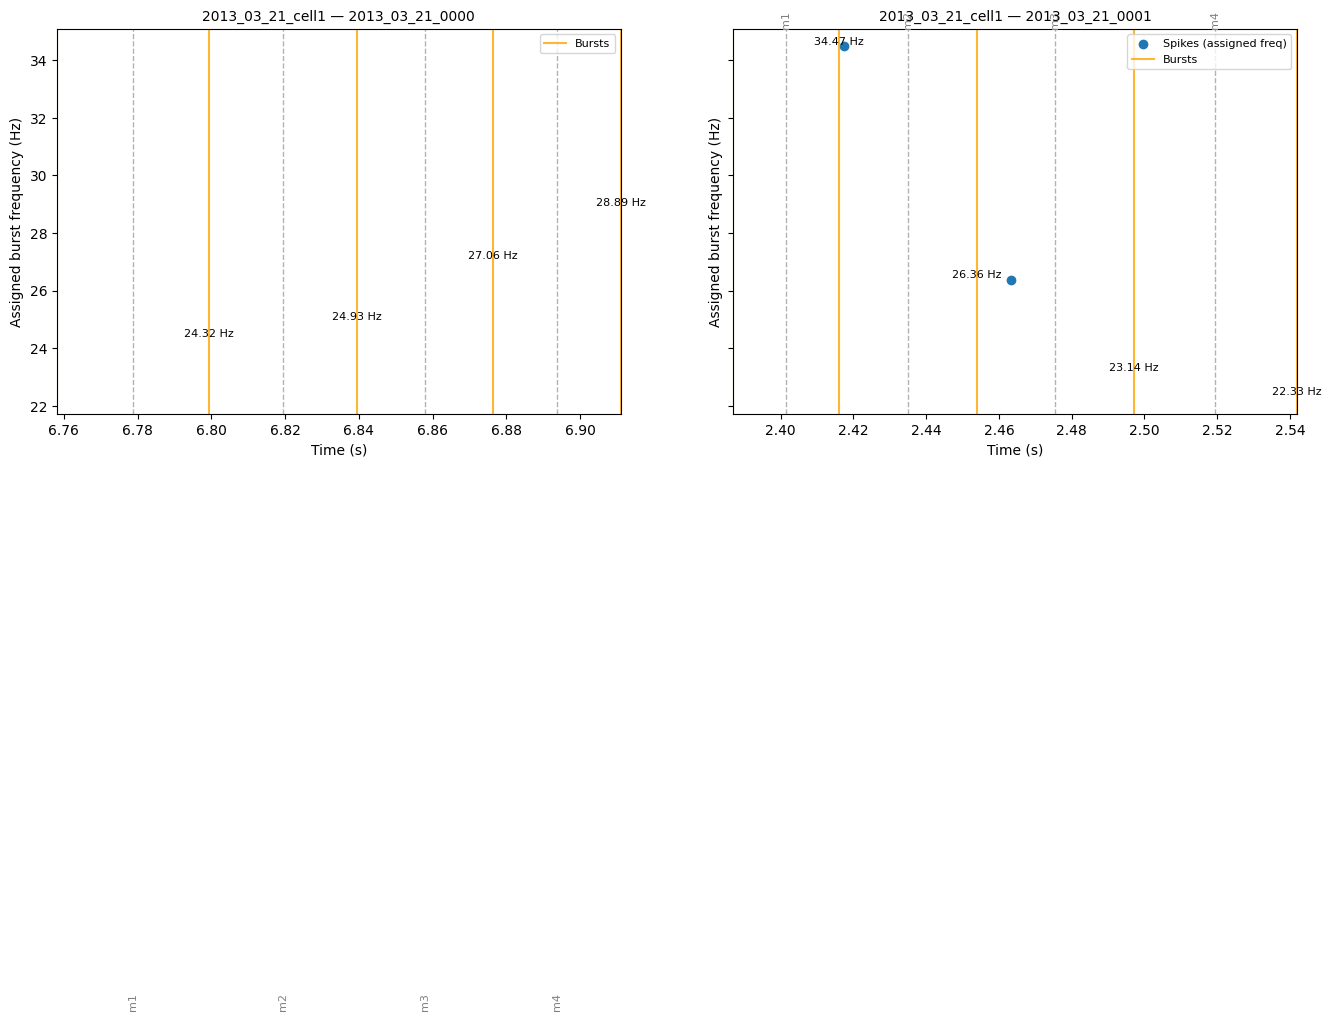

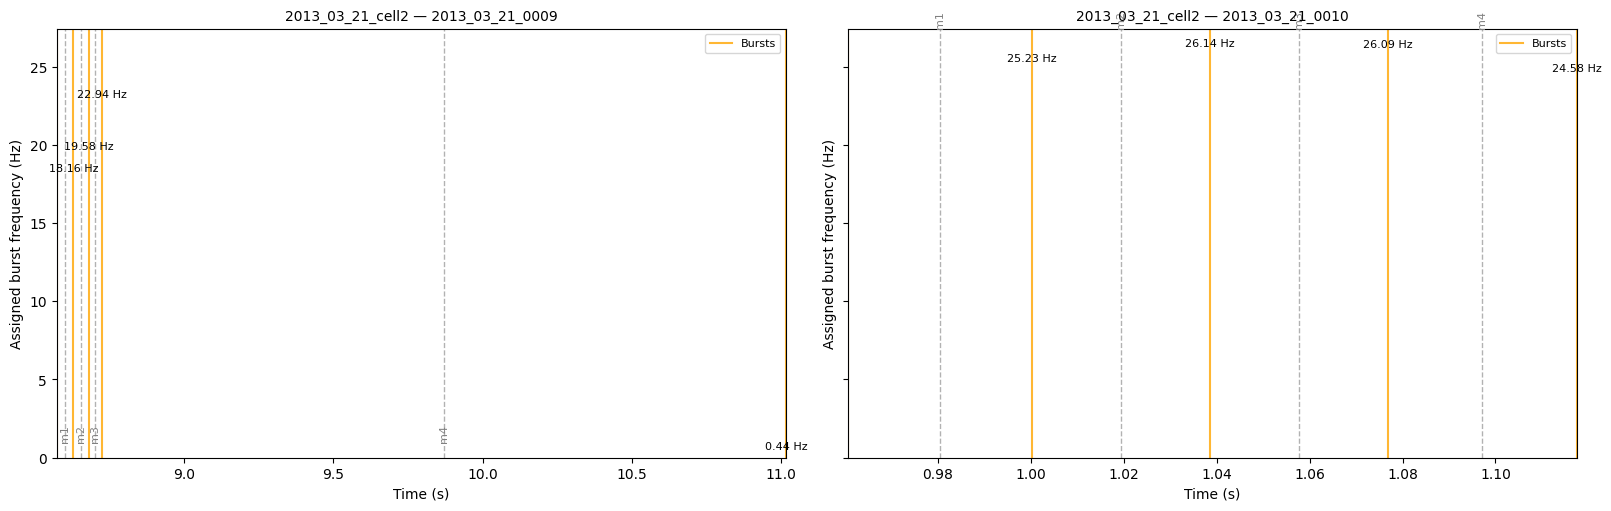

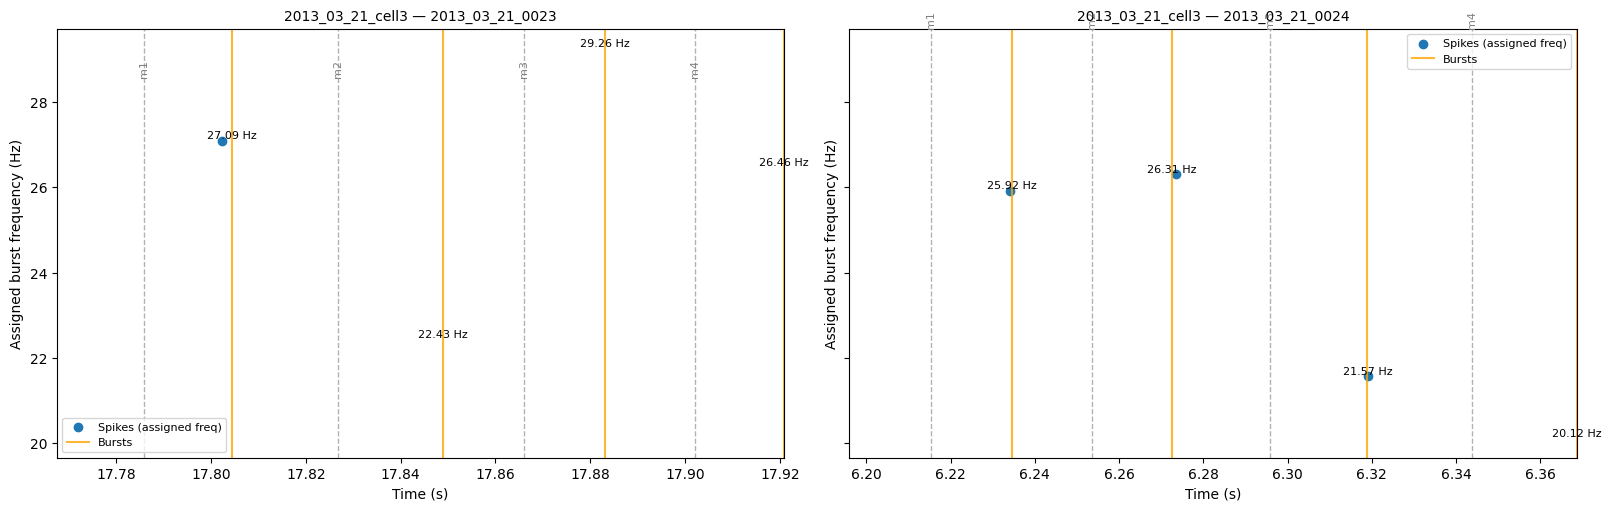

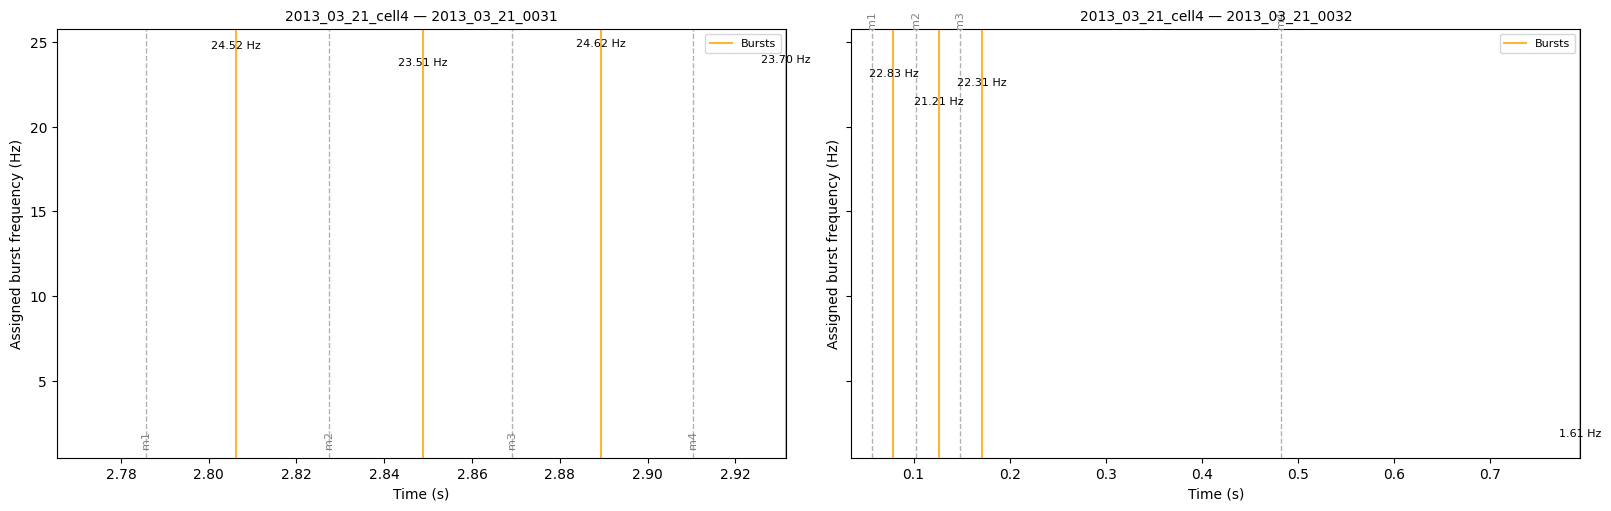

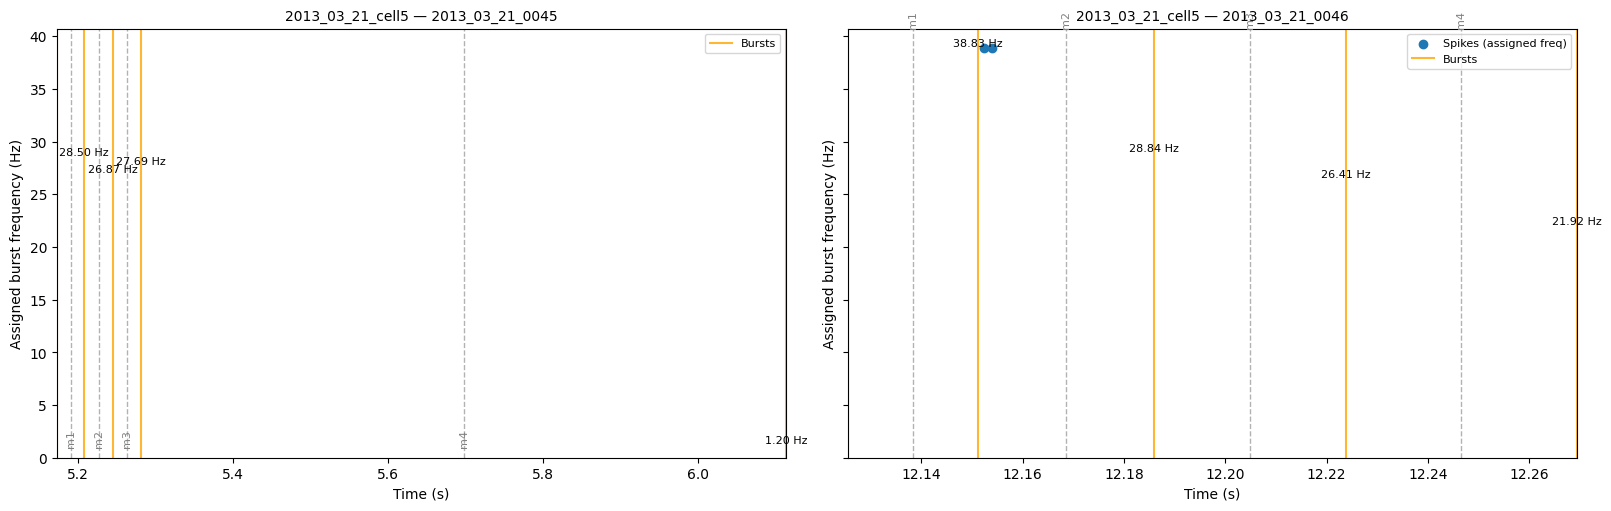

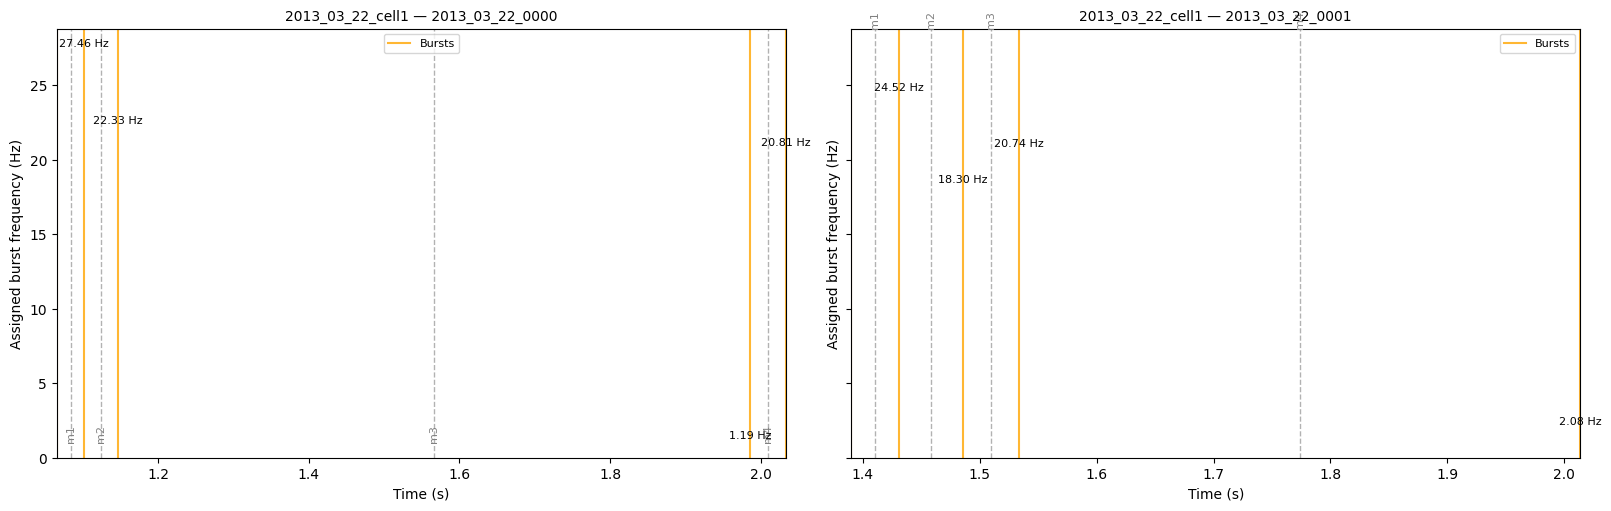

/Users/Haley/Desktop/murray-neuroscience-lab/neuro-venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or Axes decorations smaller.
  fig.canvas.print_figure(bytes_io, **kw)


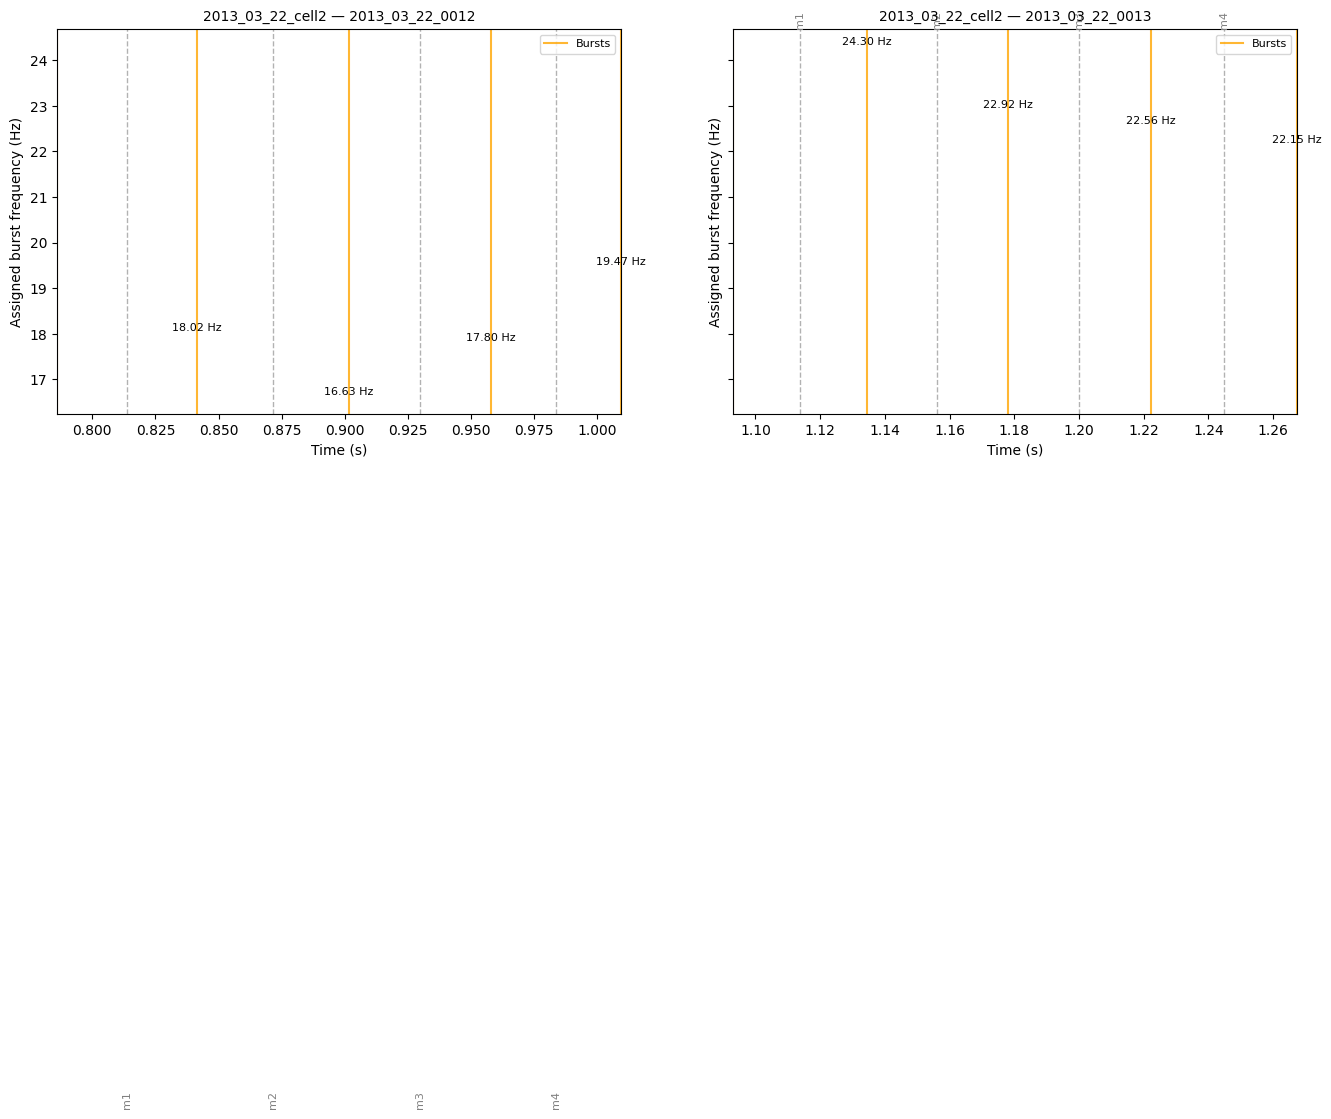

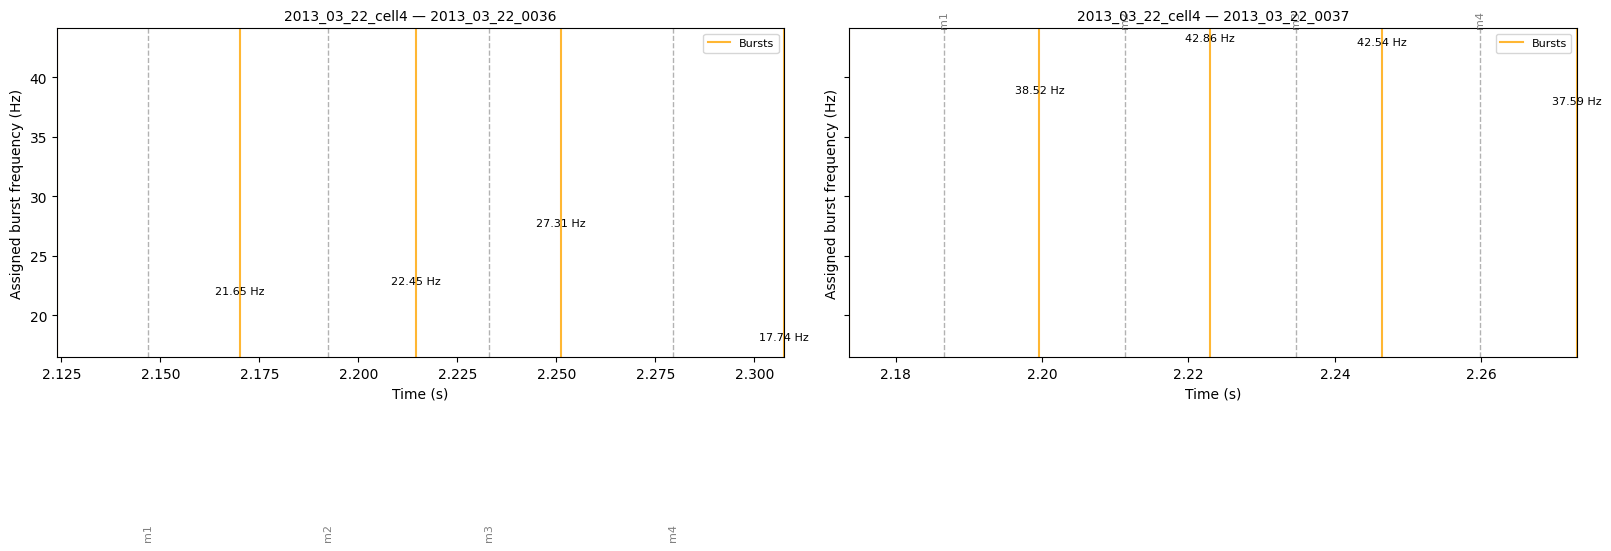

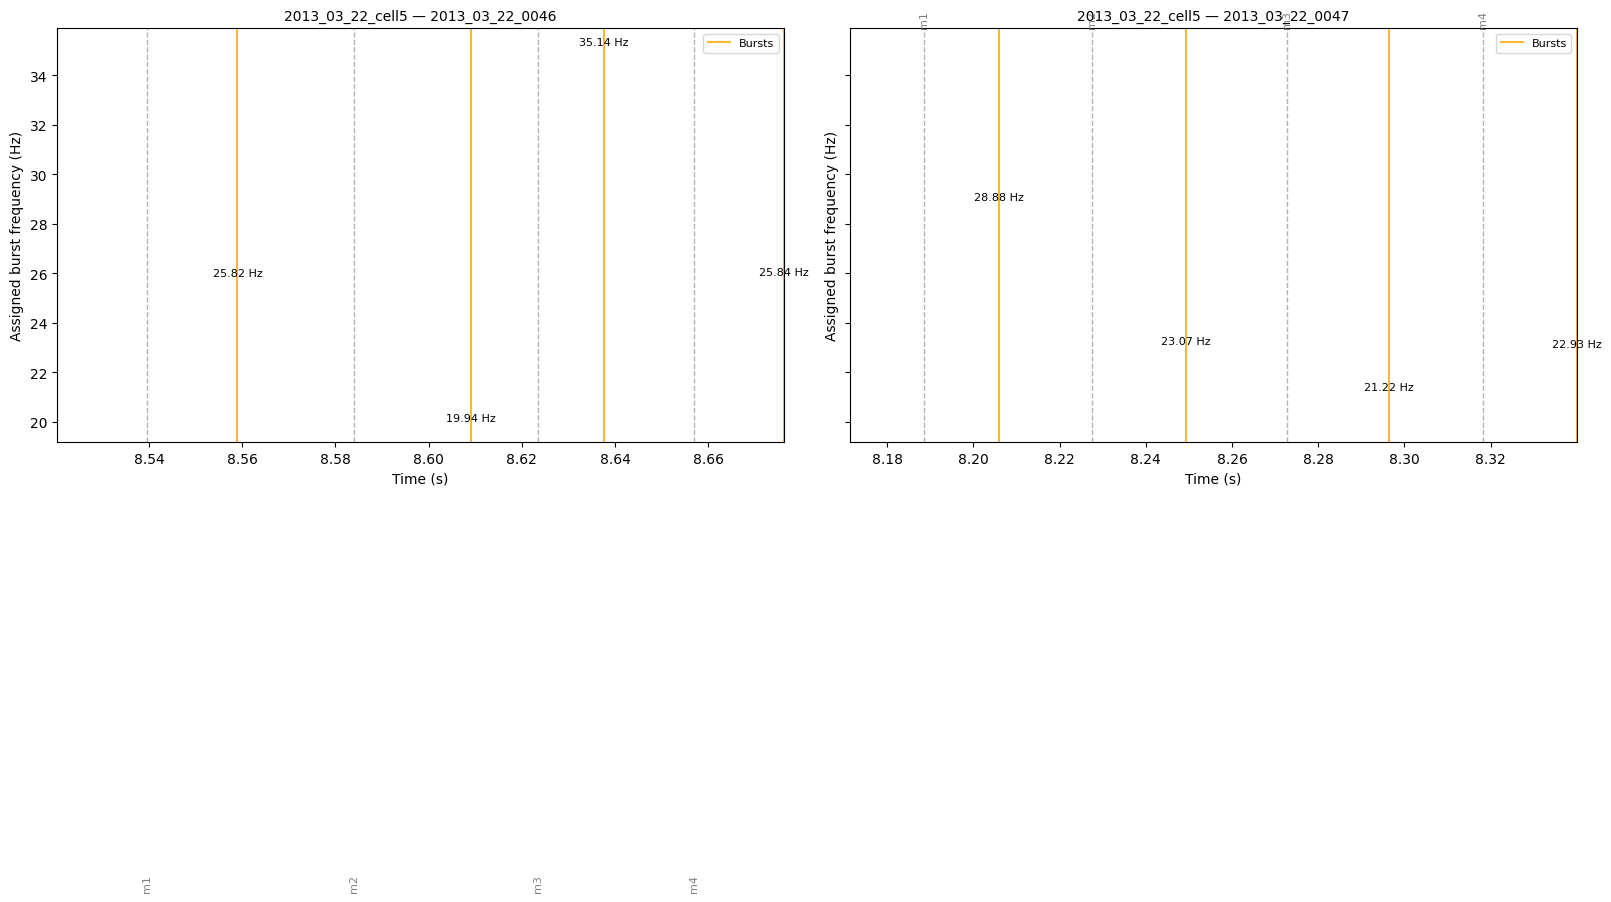

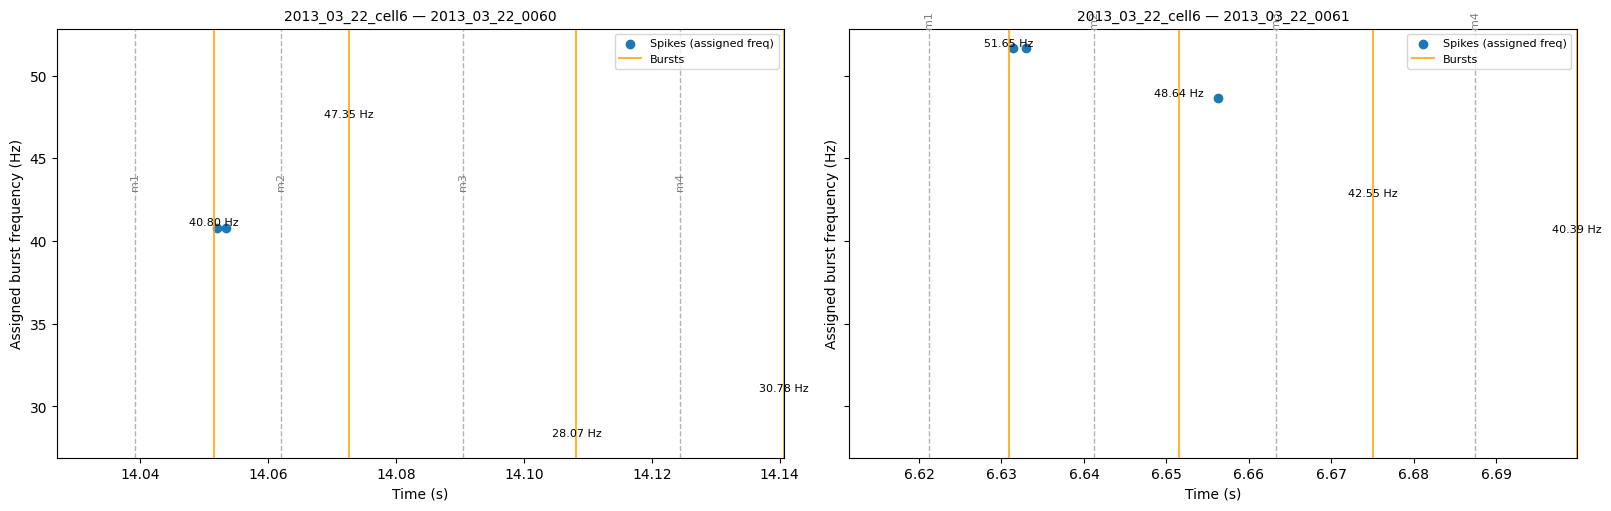

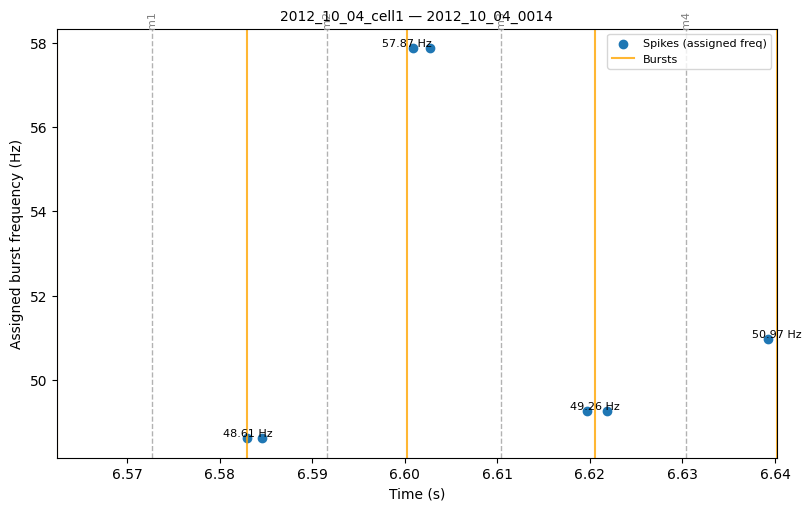

In [106]:
for sheet_name, sdf in cell_attached_dict.items():
    plot_sheet_first5_bursts(sdf, title_prefix=sheet_name)
